In [3]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import xarray as xr
import matplotlib.ticker as ticker

# import sys
# sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/")
# from EP_flux_Cal import AtmosphericDiagnostics


# Read EP flux variable = -($\overline{u'v'}$)j + (${f0 \over N^2}$ $\overline{v'b'}$) k

In [29]:
import numpy as np
import dask.array as da
from dask.diagnostics import ProgressBar

class AtmosphericDiagnostics:
    """
    Perform general atmospheric diagnostics including:
    - Anomalies
    - Eddy Momentum Flux (EMF)
    - Eddy Heat Flux (EHF)
    - Meridional EMF gradient (dEMF/dy)
    """

    def __init__(self, u, v, t, p, z, lat=None, lon=None):
        """
        Parameters:
        - u, v, t, p: Arrays (NumPy or Dask) of shape (time, z, y, x)
        - lat, lon: Optional 1D arrays for latitude and longitude
        """
        self.u = u
        self.v = v
        self.t = t
        self.p = p
        self.z = z

        # constant
        self.g = 9.81

        self.time_dim, self.z_dim, self.y_dim, self.x_dim = u.shape
        self.lat = lat if lat is not None else np.linspace(-90, 90, self.y_dim)
        self.lon = lon if lon is not None else np.linspace(0, 360, self.x_dim)

    @staticmethod
    def anomaly(data, axis=-1):
        """Compute the anomaly by subtracting mean along axis."""
        mean = np.mean(data, axis=axis, keepdims=True)
        return data - mean

    @staticmethod
    def compute_if_dask(arr):
        """Compute the result if it's a Dask array."""
        return arr.compute() if isinstance(arr, da.Array) else arr

    @staticmethod
    def EMF_dask(u, v, axis=-1):
        """Eddy Momentum Flux: u'v' (Dask-compatible)."""
        u_prime = u - u.mean(axis=axis, keepdims=True)
        v_prime = v - v.mean(axis=axis, keepdims=True)
        return u_prime * v_prime
        
    # @staticmethod    
    def cal_theta(self):
        """
        Compute potential temperature θ = T * (p0 / p)^(R/Cp) using self.t and self.p
    
        Returns:
        - theta: potential temperature [K], shape same as self.t
        """
        Rd, Cp = 287.0, 1004.0
        exponent = Rd / Cp
        theta = self.t * (100000 / self.p) ** exponent
        return theta

        
    def EHF_dask(self, t, p, v, axis=-1):
        theta = self.cal_theta()  
        theta_mean = theta.mean(axis=axis, keepdims=True)
        theta_prime = theta - theta_mean
    
        v_prime = v - v.mean(axis=axis, keepdims=True)
        b = (theta_prime / theta_mean) * self.g
        b_prime = b - b.mean(axis=axis, keepdims=True)
    
        return v_prime * b_prime
        # return v_prime * b
        

    def dEMF_dy(self, emf, use_dask=True, progress=True, chunks=(10, 20, 64, 128)):
        """
        Efficient + accurate meridional gradient of EMF (∂(u'v')/∂y) with Dask support.
    
        Parameters:
        - emf: Array (time, z, y, x), either NumPy or Dask
        - use_dask: If True, compute using Dask (lazy until .compute())
        - progress: If True and use_dask is True, show progress bar
        - chunks: Tuple to use if converting NumPy array to Dask
    
        Returns:
        - dEMF_dy: NumPy array if computed, or Dask array if lazy
        """
        # Ensure emf is a Dask array
        emf_dask = da.from_array(emf, chunks=chunks) if not isinstance(emf, da.Array) else emf
    
        # Compute dy between latitudes in meters
        R = 6.371e6
        lat_rad = np.radians(self.lat)
        dy = np.gradient(lat_rad) * R  # shape (y,)
        dy_dask = da.from_array(dy, chunks=(chunks[2],))
        dy_broadcast = dy_dask[None, None, :, None]  # shape (1, 1, y, 1)
    
        # Compute meridional gradient using Dask
        d_emf_dy = da.gradient(emf_dask, axis=2) / dy_broadcast
    
        if use_dask:
            if progress:
                from dask.diagnostics import ProgressBar
                print("dEMF_dy progress:")
                with ProgressBar():
                    return d_emf_dy.compute()
            else:
                return d_emf_dy  # Lazy result
        else:
            # Fallback to NumPy gradient
            emf_np = emf.compute() if isinstance(emf, da.Array) else emf
            dy_np = dy[np.newaxis, :, np.newaxis]
            return np.gradient(emf_np, axis=2) / dy_np



    def run_emf_ehf(self, chunks=(10, 20, 64, 128), progress=True):
        """
        Convert inputs to Dask, compute EMF and EHF with optional progress bar.
        Returns computed NumPy arrays: emf, ehf
        """
        # Convert to Dask arrays if not already
        u_dask = da.from_array(self.u, chunks=chunks) if not isinstance(self.u, da.Array) else self.u
        v_dask = da.from_array(self.v, chunks=chunks) if not isinstance(self.v, da.Array) else self.v
        t_dask = da.from_array(self.t, chunks=chunks) if not isinstance(self.t, da.Array) else self.t
        p_dask = da.from_array(self.p, chunks=chunks) if not isinstance(self.p, da.Array) else self.p

        # Compute EMF & EHF lazily
        emf_lazy = self.EMF_dask(u_dask, v_dask)
        ehf_lazy = self.EHF_dask(t_dask, p_dask, v_dask)

        # Compute with progress bar
        if progress:
            print("EMF and EHF progress:")
            with ProgressBar():
                emf = emf_lazy.compute()
                ehf = ehf_lazy.compute()
        else:
            emf = emf_lazy.compute()
            ehf = ehf_lazy.compute()

        return emf, ehf

    def dtheta(self, save=False, zonal_mean=True, output_dir=None, pr_id=None):
        """
        Compute vertical gradient of potential temperature ∂θ/∂z using central difference.
    
        Parameters:
        - theta: ndarray, shape (time, z, y, x)
        - save: bool, whether to save outputs as HDF5
        - zonal_mean: bool, whether to also compute and return zonal mean
        - output_dir: required if save=True, base path to save files
        - pr_id: required if save=True, identifier like 'PR10'
    
        Returns:
        - dtheta: ndarray, shape (time, z, y, x)
        - dtheta_zonal_mean: ndarray (time, z, y) if zonal_mean=True, else None
        """
        import os
        import gc
        import h5py
        theta = self.cal_theta()
        print("Computing ∂θ/∂z ...")
        theta = np.asarray(theta)  # ensure numpy array
        t, z, y, x = theta.shape
    
        # Reorder to (t, x, y, z) for vertical diff
        theta_txyz = np.einsum("tzyx->txyz", theta)
        theta_flat = theta_txyz.reshape(t * x * y, z)
    
        # Central and backward diff operators
        L = np.eye(z)
        central = np.roll(L, -1, axis=0) - np.roll(L, 1, axis=0)
        backward = L - np.roll(L, -1, axis=1)
    
        dtheta = theta_flat @ central
        dtheta_b = theta_flat @ backward
        dtheta[:, 0] = dtheta_b[:, 0]
        dtheta[:, -1] = dtheta_b[:, -2]
        del theta_flat, dtheta_b
        gc.collect()
    
        # Reshape back to original layout
        dtheta = dtheta.reshape(t, x, y, z)
        dtheta = np.einsum("txyz->tzyx", dtheta)  # (t, z, y, x)
    
        if zonal_mean:
            zonal = dtheta.mean(axis=3)         # (t, z, y)
            ref_mean = dtheta.mean(axis=(0, 3)) # (z, y)
    
            for i in range(zonal.shape[0]):
                posi_x, posi_y = np.where(zonal[i, :] < 0)
                zonal[i, posi_x, posi_y] = ref_mean[posi_x, posi_y]
            del ref_mean
            # Find where zonal mean is negative

            gc.collect()
        else:
            zonal = None
    
        if save:
            assert output_dir and pr_id, "Both output_dir and pr_id required if save=True"
            save_path = os.path.join(output_dir, pr_id, "dtheta")
            os.makedirs(save_path, exist_ok=True)
    
            with h5py.File(os.path.join(save_path, f"{pr_id}_dtheta_full.h5"), "w") as f:
                f.create_dataset("dtheta", data=dtheta)
            if zonal:
                with h5py.File(os.path.join(save_path, f"{pr_id}_dtheta_zonal_mean.h5"), "w") as f:
                    f.create_dataset("dtheta", data=zonal)
    
            print(f"Saved ∂θ/∂z to {save_path}")
    
        return dtheta, zonal

    def dx_along_axis(self, x, axis=1, save=False, zonal_mean=True, output_dir=None, pr_id=None, varname="x"):
        """
        Compute gradient ∂x/∂axis using central difference via matrix multiplication.
    
        Parameters:
        - x: ndarray, shape (t, z, y, x)
        - axis: int, axis along which to differentiate (e.g., 1 for vertical)
        - save: bool, whether to save outputs
        - zonal_mean: bool, whether to also return zonal mean (axis=3)
        - output_dir: required if save=True
        - pr_id: required if save=True
        - varname: str, name of the variable (for saving)
    
        Returns:
        - dx: ndarray, same shape as x
        - zonal: ndarray if zonal_mean else None
        """
        import os
        import gc
        import h5py
    
        print(f"Computing ∂({varname})/∂(axis {axis}) ...")
        x = np.asarray(x)
        assert x.ndim == 4, "Input must be 4D (t, z, y, x)"
        t, z, y, lon = x.shape
    
        # Step 1: move axis to last for matrix op
        x_perm = np.moveaxis(x, axis, -1)  # shape becomes (t, z, y, new)
        x_flat = np.einsum("tzyx->txyz", x_perm).reshape(t * lon * y, z)  # z is assumed to be axis
    
        # Step 2: construct difference matrices
        L = np.eye(z)
        central = np.roll(L, -1, axis=0) - np.roll(L, 1, axis=0)
        backward = L - np.roll(L, -1, axis=1)
    
        dx = x_flat @ central
        dx_b = x_flat @ backward
        dx[:, 0] = dx_b[:, 0]
        dx[:, -1] = dx_b[:, -2]
    
        del x_flat, dx_b
        gc.collect()
    
        # Step 3: reshape back to (t, z, y, x) consistent with your original dtheta
        dx = dx.reshape(t, lon, y, z)
        dx = np.einsum("txyz->tzyx", dx)
    
        # Step 4: zonal mean
        if zonal_mean:
            zonal = dx.mean(axis=3)         # (t, z, y)
            ref_mean = dx.mean(axis=(0, 3)) # (z, y)
            for i in range(zonal.shape[0]):
                neg = zonal[i] < 0
                zonal[i][neg] = ref_mean[neg]
            del ref_mean
            gc.collect()
        else:
            zonal = None
    
        # Step 5: save
        if save:
            assert output_dir and pr_id, "Both output_dir and pr_id required if save=True"
            save_path = os.path.join(output_dir, pr_id, varname)
            os.makedirs(save_path, exist_ok=True)
    
            with h5py.File(os.path.join(save_path, f"{pr_id}_{varname}_full.h5"), "w") as f:
                f.create_dataset(varname, data=dx)
    
            if zonal is not None:
                with h5py.File(os.path.join(save_path, f"{pr_id}_{varname}_zonal_mean.h5"), "w") as f:
                    f.create_dataset(varname, data=zonal)
    
            print(f"Saved ∂{varname}/∂axis{axis} to {save_path}")
    
        return dx, zonal

    # def Cal_N_square(self):
    #     """
    #     N^2 = g / θ_zm  * ∂θ / ∂z 
    #     """
    #     # Step 1: Cal θ_zm
    #     theta = self.cal_theta()
    #     theta_zm = theta.mean(axis=3)

    #     # Step 2: Cal ∂θ / ∂z
    #     # dtheta, dtheta_zm = self.dx_along_axis(theta, axis=1) 
    #     # dtheta = np.gradient(theta, axis=1)  # vertical derivative
    #     # dz, dz_zm         = self.dx_along_axis(self.z, axis=1) 
    #     # dz = np.gradient(self.z, axis=1)  # shape = (t, z, y, x)
    #     # print(dz.min(), dz.max())
    #     # dz = np.clip(dz, 10.0, 5000.0)  # 保證 dz 合理（10m ~ 5km）
    #     # print(dz.min(), dz.max())
    #     # dtheta_dz         = dtheta / dz

    #     # Find z is decreasing with index => dz = np.gradient(z, axis=1) casue negative
    #     # dz     = np.gradient(self.z, axis=1)  # shape (t, z, y, x)
    #     # dtheta = np.gradient(theta, axis=1)
    #     # dtheta_dz = dtheta / dz
    #     # 假設 z 是 shape (t,z,y,x)，這邊只做平均來說明
    #     z_1d = self.z.mean(axis=(0,2,3))
    #     theta_1d = theta.mean(axis=(0,2,3))
        
    #     # reverse to make z ascending
    #     sort_idx = np.argsort(z_1d)
    #     z_sorted = z_1d[sort_idx]
    #     theta_sorted = theta_1d[sort_idx]
        
    #     dtheta_dz = np.gradient(theta_sorted, z_sorted)
    #     N2 = self.g / theta_sorted * dtheta_dz



    #     # Step 3: Compute N²
    #     # N2 = self.g / theta * dtheta_dz
    #     # N2 = np.clip(N2, 1e-6, None)  # avoid instabilities

    #     return N2
    
    def Cal_N_square(self):
        theta =  self.cal_theta()
        # theta_zm = self.zonal_mean_weighted(self.cal_theta())  # (t,z,y)
        # z_zm     = self.zonal_mean_weighted(self.z)            # (t,z,y)
    
        # dz     = self.dx_along_axis(z, axis=1)
        # dtheta = self.dx_along_axis(theta, axis=1)

        dz     = np.gradient(self.z, axis=1)
        dtheta = np.gradient(theta, axis=1)
    
        # dz[np.abs(dz) < 10] = np.nan
        dtheta_dz = dtheta / dz
    
        N2 = self.g / theta * dtheta_dz
        # N2 = np.clip(N2, 1e-6, 1e-3)
        N2[N2 < 1E-7] = 1E-7
    
        return N2



    def f0(self):
        """
        Return Coriolis parameter f0 as a function of latitude (shape: (y,))
        """
        omega = 7.2921e-5  # Earth's rotation rate in rad/s
        return 2 * omega * np.sin(np.deg2rad(self.lat))  # shape (y,)

    def ep_flux(self, axis=-1, chunks=(10, 20, 64, 128)):
        """
        Compute EP flux components using precomputed EMF and EHF:
        - F_j = -EMF = -u'v'
        - F_k = (f0 / N^2) * EHF = (f0 / N^2) * v'b'
    
        Returns:
        - F_j: ndarray, shape (t, z, y, x)
        - F_k: ndarray, shape (t, z, y, x)
        """
        # Step 1: Compute EMF and EHF using your method
        emf, ehf = self.run_emf_ehf()
    
        # Step 2: Compute θ and ∂θ/∂z to get N²
        # theta = self.cal_theta()
        # theta_zm = theta.mean(axis=3)  # shape (t, z, y)
    
        # dtheta, _ = self.dx_along_axis(theta, axis=1, zonal_mean=False, varname="dtheta") # FIXED: axis should = 1 (to z)
        # dz, _     = self.dx_along_axis(self.z, axis=1, zonal_mean=False, varname="dz")
        # dtheta = np.gradient(theta, axis=1)
        # dz     = np.gradient(self.z, axis=1)
        # dtheta_dz = dtheta / dz
    
        # N2 = self.g / theta_zm[:, :, :, np.newaxis] * dtheta_dz  # shape (t, z, y, x)
        N2 = self.Cal_N_square()
        # N2_zm  = N2 # self.zonal_mean_weighted(N2)  # shape (t, z, y)
        # ehf_zm = self.zonal_mean_weighted(ehf)  # shape (t, z, y)
    
        # Step 3: Compute Coriolis parameter f0
        # f0_array = self.f0()[np.newaxis, np.newaxis, :, np.newaxis]  # shape (1, 1, y, 1)
        f0_array = self.f0()[np.newaxis, np.newaxis, :, np.newaxis]  # shape (1,1,y)

    
        # Step 4: Compute EP flux components
        F_j = -emf  # -u'v's
        F_k = f0_array / N2 * ehf #np.mean(ehf, axis=3, keepdims=True) #* np.cos(np.deg2rad(self.lat))[np.newaxis, np.newaxis, :, np.newaxis]
        
        # F_j = -emf * np.cos(np.deg2rad(self.lat))[np.newaxis, np.newaxis, :, np.newaxis]  # -u'v'
        # F_k = f0_array / N2 * ehf * np.cos(np.deg2rad(self.lat))[np.newaxis, np.newaxis, :, np.newaxis] #np.mean(ehf, axis=3, keepdims=True) #* np.cos(np.deg2rad(self.lat))[np.newaxis, np.newaxis, :, np.newaxis]
        
        
        # with np.errstate(divide='ignore', invalid='ignore'):
            # F_k = np.where(N2 > 1e-6, f0_array * ehf / N2, 0.0)
        print("Fj.shape:", F_j.shape)
        print("Fk.shape:", F_k.shape)
        

        return F_j, F_k

    def zonal_mean_weighted(self, data):
        """
        Compute area-weighted zonal mean using cos(latitude) weights.
    
        Parameters:
        - data: ndarray, shape (t, z, y, x)
    
        Returns:
        - weighted_zonal_mean: ndarray, shape (t, z, y)
        """
        cosphi = np.cos(np.deg2rad(self.lat))  # shape (y,)
        weights = cosphi / cosphi.mean()       # normalize for stability
    
        # Reshape to broadcast weights: shape (1, 1, y, 1)
        w = weights[None, None, :, None]
    
        weighted_sum = np.sum(data * w, axis=3)     # sum over x (longitude)
        weight_total = np.sum(w, axis=3)            # sum weights along x
        zonal_mean = weighted_sum / weight_total
    
        return zonal_mean






# Read EP flux variable = -($\overline{u'v'}$)j + (${f0 \over \overline{\theta_p}}$ $\overline{v'\theta'}$) k

In [105]:
import numpy as np
import dask.array as da
from dask.diagnostics import ProgressBar

class AtmosphericDiagnostics:
    """
    Perform general atmospheric diagnostics including:
    - Anomalies
    - Eddy Momentum Flux (EMF)
    - Eddy Heat Flux (EHF)
    - Meridional EMF gradient (dEMF/dy)
    """

    def __init__(self, u, v, t, p, z, lat=None, lon=None):
        """
        Parameters:
        - u, v, t, p: Arrays (NumPy or Dask) of shape (time, z, y, x)
        - lat, lon: Optional 1D arrays for latitude and longitude
        """
        self.u = u
        self.v = v
        self.t = t
        self.p = p
        self.z = z

        # constant
        self.g = 9.81

        self.time_dim, self.z_dim, self.y_dim, self.x_dim = u.shape
        self.lat = lat if lat is not None else np.linspace(-90, 90, self.y_dim)
        self.lon = lon if lon is not None else np.linspace(0, 360, self.x_dim)

    @staticmethod
    def anomaly(data, axis=-1):
        """Compute the anomaly by subtracting mean along axis."""
        mean = np.mean(data, axis=axis, keepdims=True)
        return data - mean

    @staticmethod
    def compute_if_dask(arr):
        """Compute the result if it's a Dask array."""
        return arr.compute() if isinstance(arr, da.Array) else arr

    @staticmethod
    def EMF_dask(u, v, axis=-1):
        """Eddy Momentum Flux: u'v' (Dask-compatible)."""
        u_prime = u - u.mean(axis=axis, keepdims=True)
        v_prime = v - v.mean(axis=axis, keepdims=True)
        return u_prime * v_prime
        
    # @staticmethod    
    def cal_theta(self):
        """
        Compute potential temperature θ = T * (p0 / p)^(R/Cp) using self.t and self.p
    
        Returns:
        - theta: potential temperature [K], shape same as self.t
        """
        Rd, Cp = 287.0, 1004.0
        exponent = Rd / Cp
        p1d = np.mean(self.p, axis=(0,2,3))
        theta = self.t * (100000 / p1d[np.newaxis,:,np.newaxis,np.newaxis]) ** exponent
        # pp0 = (p0/p[np.newaxis,:,np.newaxis,np.newaxis])**kappa

        return theta

        
    def EHF_dask(self, t, p, v, axis=-1):
        theta = self.cal_theta()  
        theta_mean = theta.mean(axis=axis, keepdims=True)
        theta_prime = theta - theta_mean
    
        v_prime = v - v.mean(axis=axis, keepdims=True)
        # b = (theta_prime / theta_mean) * self.g
        # b_prime = b - b.mean(axis=axis, keepdims=True)
    
        return v_prime * theta_prime
        # return v_prime * b
        

    def dEMF_dy(self, emf, use_dask=True, progress=True, chunks=(10, 20, 64, 128)):
        """
        Efficient + accurate meridional gradient of EMF (∂(u'v')/∂y) with Dask support.
    
        Parameters:
        - emf: Array (time, z, y, x), either NumPy or Dask
        - use_dask: If True, compute using Dask (lazy until .compute())
        - progress: If True and use_dask is True, show progress bar
        - chunks: Tuple to use if converting NumPy array to Dask
    
        Returns:
        - dEMF_dy: NumPy array if computed, or Dask array if lazy
        """
        # Ensure emf is a Dask array
        emf_dask = da.from_array(emf, chunks=chunks) if not isinstance(emf, da.Array) else emf
    
        # Compute dy between latitudes in meters
        R = 6.371e6
        lat_rad = np.radians(self.lat)
        dy = np.gradient(lat_rad) * R  # shape (y,)
        dy_dask = da.from_array(dy, chunks=(chunks[2],))
        dy_broadcast = dy_dask[None, None, :, None]  # shape (1, 1, y, 1)
    
        # Compute meridional gradient using Dask
        d_emf_dy = da.gradient(emf_dask, axis=2) / dy_broadcast
    
        if use_dask:
            if progress:
                from dask.diagnostics import ProgressBar
                print("dEMF_dy progress:")
                with ProgressBar():
                    return d_emf_dy.compute()
            else:
                return d_emf_dy  # Lazy result
        else:
            # Fallback to NumPy gradient
            emf_np = emf.compute() if isinstance(emf, da.Array) else emf
            dy_np = dy[np.newaxis, :, np.newaxis]
            return np.gradient(emf_np, axis=2) / dy_np



    def run_emf_ehf(self, chunks=(10, 20, 64, 128), progress=True):
        """
        Convert inputs to Dask, compute EMF and EHF with optional progress bar.
        Returns computed NumPy arrays: emf, ehf
        """
        # Convert to Dask arrays if not already
        u_dask = da.from_array(self.u, chunks=chunks) if not isinstance(self.u, da.Array) else self.u
        v_dask = da.from_array(self.v, chunks=chunks) if not isinstance(self.v, da.Array) else self.v
        t_dask = da.from_array(self.t, chunks=chunks) if not isinstance(self.t, da.Array) else self.t
        p_dask = da.from_array(self.p, chunks=chunks) if not isinstance(self.p, da.Array) else self.p

        # Compute EMF & EHF lazily
        emf_lazy = self.EMF_dask(u_dask, v_dask)
        ehf_lazy = self.EHF_dask(t_dask, p_dask, v_dask)

        # Compute with progress bar
        if progress:
            print("EMF and EHF progress:")
            with ProgressBar():
                emf = emf_lazy.compute()
                ehf = ehf_lazy.compute()
        else:
            emf = emf_lazy.compute()
            ehf = ehf_lazy.compute()

        return emf, ehf

    def dtheta(self, save=False, zonal_mean=True, output_dir=None, pr_id=None):
        """
        Compute vertical gradient of potential temperature ∂θ/∂z using central difference.
    
        Parameters:
        - theta: ndarray, shape (time, z, y, x)
        - save: bool, whether to save outputs as HDF5
        - zonal_mean: bool, whether to also compute and return zonal mean
        - output_dir: required if save=True, base path to save files
        - pr_id: required if save=True, identifier like 'PR10'
    
        Returns:
        - dtheta: ndarray, shape (time, z, y, x)
        - dtheta_zonal_mean: ndarray (time, z, y) if zonal_mean=True, else None
        """
        import os
        import gc
        import h5py
        theta = self.cal_theta()
        print("Computing ∂θ/∂z ...")
        theta = np.asarray(theta)  # ensure numpy array
        t, z, y, x = theta.shape
    
        # Reorder to (t, x, y, z) for vertical diff
        theta_txyz = np.einsum("tzyx->txyz", theta)
        theta_flat = theta_txyz.reshape(t * x * y, z)
    
        # Central and backward diff operators
        L = np.eye(z)
        central = np.roll(L, -1, axis=0) - np.roll(L, 1, axis=0)
        backward = L - np.roll(L, -1, axis=1)
    
        dtheta = theta_flat @ central
        dtheta_b = theta_flat @ backward
        dtheta[:, 0] = dtheta_b[:, 0]
        dtheta[:, -1] = dtheta_b[:, -2]
        del theta_flat, dtheta_b
        gc.collect()
    
        # Reshape back to original layout
        dtheta = dtheta.reshape(t, x, y, z)
        dtheta = np.einsum("txyz->tzyx", dtheta)  # (t, z, y, x)
    
        if zonal_mean:
            zonal = dtheta.mean(axis=3)         # (t, z, y)
            ref_mean = dtheta.mean(axis=(0, 3)) # (z, y)
    
            for i in range(zonal.shape[0]):
                posi_x, posi_y = np.where(zonal[i, :] < 0)
                zonal[i, posi_x, posi_y] = ref_mean[posi_x, posi_y]
            del ref_mean
            # Find where zonal mean is negative

            gc.collect()
        else:
            zonal = None
    
        if save:
            assert output_dir and pr_id, "Both output_dir and pr_id required if save=True"
            save_path = os.path.join(output_dir, pr_id, "dtheta")
            os.makedirs(save_path, exist_ok=True)
    
            with h5py.File(os.path.join(save_path, f"{pr_id}_dtheta_full.h5"), "w") as f:
                f.create_dataset("dtheta", data=dtheta)
            if zonal:
                with h5py.File(os.path.join(save_path, f"{pr_id}_dtheta_zonal_mean.h5"), "w") as f:
                    f.create_dataset("dtheta", data=zonal)
    
            print(f"Saved ∂θ/∂z to {save_path}")
    
        return dtheta, zonal

    def dx_along_axis(self, x, axis=1, save=False, zonal_mean=True, output_dir=None, pr_id=None, varname="x"):
        """
        Compute gradient ∂x/∂axis using central difference via matrix multiplication.
    
        Parameters:
        - x: ndarray, shape (t, z, y, x)
        - axis: int, axis along which to differentiate (e.g., 1 for vertical)
        - save: bool, whether to save outputs
        - zonal_mean: bool, whether to also return zonal mean (axis=3)
        - output_dir: required if save=True
        - pr_id: required if save=True
        - varname: str, name of the variable (for saving)
    
        Returns:
        - dx: ndarray, same shape as x
        - zonal: ndarray if zonal_mean else None
        """
        import os
        import gc
        import h5py
    
        print(f"Computing ∂({varname})/∂(axis {axis}) ...")
        x = np.asarray(x)
        assert x.ndim == 4, "Input must be 4D (t, z, y, x)"
        t, z, y, lon = x.shape
    
        # Step 1: move axis to last for matrix op
        x_perm = np.moveaxis(x, axis, -1)  # shape becomes (t, z, y, new)
        x_flat = np.einsum("tzyx->txyz", x_perm).reshape(t * lon * y, z)  # z is assumed to be axis
    
        # Step 2: construct difference matrices
        L = np.eye(z)
        central = np.roll(L, -1, axis=0) - np.roll(L, 1, axis=0)
        backward = L - np.roll(L, -1, axis=1)
    
        dx = x_flat @ central
        dx_b = x_flat @ backward
        dx[:, 0] = dx_b[:, 0]
        dx[:, -1] = dx_b[:, -2]
    
        del x_flat, dx_b
        gc.collect()
    
        # Step 3: reshape back to (t, z, y, x) consistent with your original dtheta
        dx = dx.reshape(t, lon, y, z)
        dx = np.einsum("txyz->tzyx", dx)
    
        # Step 4: zonal mean
        if zonal_mean:
            zonal = dx.mean(axis=3)         # (t, z, y)
            ref_mean = dx.mean(axis=(0, 3)) # (z, y)
            for i in range(zonal.shape[0]):
                neg = zonal[i] < 0
                zonal[i][neg] = ref_mean[neg]
            del ref_mean
            gc.collect()
        else:
            zonal = None
    
        # Step 5: save
        if save:
            assert output_dir and pr_id, "Both output_dir and pr_id required if save=True"
            save_path = os.path.join(output_dir, pr_id, varname)
            os.makedirs(save_path, exist_ok=True)
    
            with h5py.File(os.path.join(save_path, f"{pr_id}_{varname}_full.h5"), "w") as f:
                f.create_dataset(varname, data=dx)
    
            if zonal is not None:
                with h5py.File(os.path.join(save_path, f"{pr_id}_{varname}_zonal_mean.h5"), "w") as f:
                    f.create_dataset(varname, data=zonal)
    
            print(f"Saved ∂{varname}/∂axis{axis} to {save_path}")
    
        return dx, zonal

    # def Cal_N_square(self):
    #     """
    #     N^2 = g / θ_zm  * ∂θ / ∂z 
    #     """
    #     # Step 1: Cal θ_zm
    #     theta = self.cal_theta()
    #     theta_zm = theta.mean(axis=3)

    #     # Step 2: Cal ∂θ / ∂z
    #     # dtheta, dtheta_zm = self.dx_along_axis(theta, axis=1) 
    #     # dtheta = np.gradient(theta, axis=1)  # vertical derivative
    #     # dz, dz_zm         = self.dx_along_axis(self.z, axis=1) 
    #     # dz = np.gradient(self.z, axis=1)  # shape = (t, z, y, x)
    #     # print(dz.min(), dz.max())
    #     # dz = np.clip(dz, 10.0, 5000.0)  # 保證 dz 合理（10m ~ 5km）
    #     # print(dz.min(), dz.max())
    #     # dtheta_dz         = dtheta / dz

    #     # Find z is decreasing with index => dz = np.gradient(z, axis=1) casue negative
    #     # dz     = np.gradient(self.z, axis=1)  # shape (t, z, y, x)
    #     # dtheta = np.gradient(theta, axis=1)
    #     # dtheta_dz = dtheta / dz
    #     # 假設 z 是 shape (t,z,y,x)，這邊只做平均來說明
    #     z_1d = self.z.mean(axis=(0,2,3))
    #     theta_1d = theta.mean(axis=(0,2,3))
        
    #     # reverse to make z ascending
    #     sort_idx = np.argsort(z_1d)
    #     z_sorted = z_1d[sort_idx]
    #     theta_sorted = theta_1d[sort_idx]
        
    #     dtheta_dz = np.gradient(theta_sorted, z_sorted)
    #     N2 = self.g / theta_sorted * dtheta_dz



    #     # Step 3: Compute N²
    #     # N2 = self.g / theta * dtheta_dz
    #     # N2 = np.clip(N2, 1e-6, None)  # avoid instabilities

    #     return N2
    def Cal_N_square(self):
        """
        Compute Brunt–Väisälä frequency squared (N²), shape (t, z, y, x)
        N² = g / θ * ∂θ / ∂z, where z increases with index
        """
        theta = self.cal_theta()  # shape (t, z, y, x)
        p = self.p                # shape (t, z, y, x)
    
        # dtheta = np.gradient(theta, axis=1)  # ∂θ/∂z
        # dz     = np.gradient(p, axis=1)      # ∂z/∂z 方向（應該是正的）
        
        # dtheta_dz = dtheta / dz              # full 4D derivative
        # dtheta_dz[dtheta_dz == 0.] = np.nan

        # dtheta_dz_tm = np.nanmean(dtheta_dz, axis=0)
    
        # N2 = dtheta_dz_tm    


        p1d = np.mean(p, axis=(0,2,3))
        print(p1d)
        dp  = np.gradient(p1d)[np.newaxis,:,np.newaxis]

        theta_prime = np.nanmean(theta, axis=-1)
        dthdp = np.gradient(theta_prime, edge_order=2)[1]/dp # dthdp = d(theta_bar)/dp
        dthdp[dthdp==0] = np.NaN
        dthdp = np.nanmean(dthdp,axis=0)[np.newaxis,:]
        print(dthdp)
        
        return dthdp



    def f0(self):
        """
        Return Coriolis parameter f0 as a function of latitude (shape: (y,))
        """
        omega = 7.2921e-5  # Earth's rotation rate in rad/s
        return 2 * omega * np.sin(np.deg2rad(self.lat))  # shape (y,)

    def dtheta_dp(self):
        theta = self.cal_theta()
        dtheta = np.gradient(theta, axis=1)

        dp     = np.gradient(self.p, axis=1)
        dtheta_dp = dtheta / dp
        return dtheta_dp
        
    def ep_flux(self, axis=-1, chunks=(10, 20, 64, 128)):
        """
        Compute EP flux components using precomputed EMF and EHF:
        - F_j = -EMF = -u'v'
        - F_k = (f0 / N^2) * EHF = (f0 / N^2) * v'b'
    
        Returns:
        - F_j: ndarray, shape (t, z, y, x)
        - F_k: ndarray, shape (t, z, y, x)
        """
        a = 6.371E6
        acos = a * np.cos(np.deg2rad(self.lat))
        # Step 1: Compute EMF and EHF using your method
        emf, ehf = self.run_emf_ehf()
        emf_zm = np.mean(emf, axis=-1)
        ehf_zm = np.mean(ehf, axis=-1)
        
        # Step 2: \partial theta / \partial p
        N2 = self.Cal_N_square()
        print(N2.shape)

        # Step 3: Compute Coriolis parameter f0
        # f0_array = self.f0()[np.newaxis, np.newaxis, :, np.newaxis]  # shape (1, 1, y, 1)
        f0_array = self.f0()[np.newaxis, np.newaxis, :]  # shape (1,1,y)

    
        # Step 4: Compute EP flux components
        F_j = -emf_zm  # -u'v'
        print(ehf_zm.shape, N2.shape, F_j.shape)
        EHF_dthdp = ehf_zm / N2
        F_k = f0_array * EHF_dthdp #np.mean(ehf, axis=3, keepdims=True) #* np.cos(np.deg2rad(self.lat))[np.newaxis, np.newaxis, :, np.newaxis]
        
        # F_j = -emf * np.cos(np.deg2rad(self.lat))[np.newaxis, np.newaxis, :, np.newaxis]  # -u'v'
        # F_k = f0_array / N2 * ehf * np.cos(np.deg2rad(self.lat))[np.newaxis, np.newaxis, :, np.newaxis] #np.mean(ehf, axis=3, keepdims=True) #* np.cos(np.deg2rad(self.lat))[np.newaxis, np.newaxis, :, np.newaxis]
        
        
        # with np.errstate(divide='ignore', invalid='ignore'):
            # F_k = np.where(N2 > 1e-6, f0_array * ehf / N2, 0.0)
        print("Fj.shape:", F_j.shape)
        print("Fk.shape:", F_k.shape)
        

        return F_j, F_k,EHF_dthdp

    def zonal_mean_weighted(self, data):
        """
        Compute area-weighted zonal mean using cos(latitude) weights.
    
        Parameters:
        - data: ndarray, shape (t, z, y, x)
    
        Returns:
        - weighted_zonal_mean: ndarray, shape (t, z, y)
        """
        cosphi = np.cos(np.deg2rad(self.lat))  # shape (y,)
        weights = cosphi / cosphi.mean()       # normalize for stability
    
        # Reshape to broadcast weights: shape (1, 1, y, 1)
        w = weights[None, None, :, None]
    
        weighted_sum = np.sum(data * w, axis=3)     # sum over x (longitude)
        weight_total = np.sum(w, axis=3)            # sum weights along x
        zonal_mean = weighted_sum / weight_total
    
        return zonal_mean






# Read variables

In [5]:
PR = 10
u_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/u/PR{PR}_500_20000day_6hourly_u.dat"
v_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/v/PR{PR}_500_20000day_6hourly_v.dat"

t_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/t/PR{PR}_500_20000day_6hourly_t.dat"
p_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/p/PR{PR}_500_20000day_6hourly_p.dat"
ps_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/ps/PR{PR}_500_20000day_6hourly_ps.dat"

z_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/z/PR{PR}_500_20000day_6hourly_z.dat"


In [6]:
with h5py.File(u_file, "r") as ds:
    u = np.asarray(ds["u"][:])

with h5py.File(v_file, "r") as ds:
    v = np.asarray(ds["v"][:])

with h5py.File(t_file, "r") as ds:
    t = np.asarray(ds["t"][:])

with h5py.File(p_file, "r") as ds:
    p = np.asarray(ds["p"][:])

# with h5py.File(z_file, "r") as ds:
#     z = np.asarray(ds["z"][:])

In [11]:
with h5py.File(z_file, "r") as ds:
    z = np.asarray(ds["z"][:])

# Jucker method EP flux 

In [28]:
lat = np.linspace(90,-90,64)
t.shape

(78000, 20, 64, 128)

In [31]:
# import aostools_functions as ac
import sys
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
import aostools_functions as ac
# print(z.shape)
start_idx = 50000
end_idx   = 70000

p_1d = p[start_idx:end_idx].mean(axis=(0,2,3))
print(p_1d.shape)
ep1,ep2,div1,div2 = ac.ComputeEPfluxDiv(lat,p_1d/100,u[start_idx:end_idx],v[start_idx:end_idx],t[start_idx:end_idx])


(20,)


In [32]:
a0 = 6376.0e3
lat = np.linspace(90,-90,64)
cosphi = np.cos(np.deg2rad(lat))
time_len = u[start_idx:end_idx].shape[0]
time_coord = np.arange(time_len)  # or use your actual time values if available

f1 = xr.DataArray(ep1, dims=["time", "level", "latitude"],
                  coords={"time": time_coord,
                          "level": p_1d/100,
                          "latitude": lat},
                  name='f1')

f2 = xr.DataArray(ep2, dims=["time", "level", "latitude"],
                  coords={"time": time_coord,
                          "level": p_1d/100,
                          "latitude": lat},
                  name='f2')

F_phi = a0*cosphi*f1
F_p = a0*cosphi*f2



In [34]:
def CorrectAspect(x,y):
	# x-coordinate in kilometers = a*phi
	delta_x = 6.4e3*np.deg2rad(x[-1]-x[0])
	# delta_y = y[-1] - y[0]
	delta_y = max(y) - min(y)
	# figure aspect ratio
	width,height = GetAxSize(plt.gcf(),plt.gca())
	return delta_y/height,delta_x/width

In [35]:
def GetAxSize(fig,ax,dpi=False):
	"""get width and height of a given axis.
	   output is in inches if dpi=False, in dpi if dpi=True
	"""
	bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
	width, height = bbox.width, bbox.height
	if dpi:
		width *= fig.dpi
		height *= fig.dpi
	return width, height

In [36]:
def Baldwin(F_phi,F_p,pres='level',lat='latitude',xlim=[-90,90]):
	# Baldwin et al JAS (1985), Figure 6E
	# F_phi = a*cosphi*(-u'v')
	# F_p   = a*cosphi*(f*v'theta'/theta_p)
	# log(p) coordinates. Note here that
	#  they say they use ln(p) as vertical coordinate,
	#  but in fact they use log10(p)
	#  They do not say what value they use for H either,
	#   so we have to guess here that it's the same as Palmer (1981)
	H = 6.4e3
	p0 = 1000.
	z = -H*np.log(F_p[pres]/p0)
	# They use theta_z instead of theta_p, so we need to convert
	F_z = -F_p*H/p0
	# Then, they multiply by exp(z/H) = p0/0
	# Fhat_phi = F_phi*exp(z/H) = F_phi*p0/p
	# Fhat_p   = F_z*exp(z/H) = F_z*p0/p
	# in addition,
	factr = p0/F_p[pres]
	# also correct for aspect ratio
	dx,dy = CorrectAspect(xlim,z*1.e-3)
	return factr*dx*F_phi,factr*dy*F_z

In [37]:
def set_size(w,h, ax=None):
	""" w, h: width, height in inches """
	if not ax: ax=plt.gca()
	l = ax.figure.subplotpars.left
	r = ax.figure.subplotpars.right
	t = ax.figure.subplotpars.top
	b = ax.figure.subplotpars.bottom
	figw = float(w)/(r-l)
	figh = float(h)/(t-b)
	ax.figure.set_size_inches(figw, figh)

In [37]:
p_1d/100

array([ 18.432606,  73.73042 , 124.418526, 174.76485 , 225.00235 ,
       275.1945  , 325.3529  , 375.5066  , 425.63794 , 475.77298 ,
       525.89496 , 576.02045 , 626.13184 , 676.2458  , 726.36743 ,
       776.4846  , 826.60516 , 876.7117  , 926.81256 , 976.9241  ],
      dtype=float32)

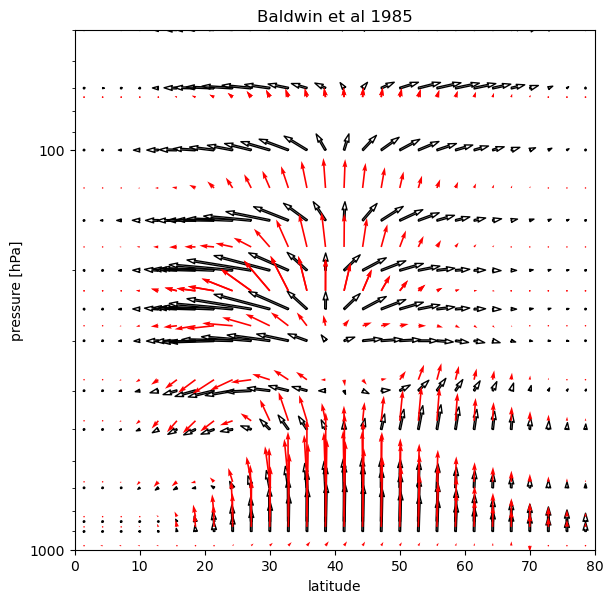

In [38]:
Fx = {}
Fy = {}
scale = "log"
# Baldwin et al 1985, Figure 6:
method = 'Baldwin'
quiv_args = {'angles':'uv','scale_units':'inches','linewidths':1,'edgecolors':'k','color':'none'}

# f1,f2,F_phi,F_p,div1,div2 = ReadERA(slice('1979-01-05','1979-03-03'),pskip=1,divs=True)
lat = F_phi.sel(latitude=slice(80,0)).latitude
# pres = np.array([50,70,100,150,200,300,400,500,700,850])
pres = np.array([50,70,100,150,200,250,300,400,500,700,850,900,10000])

fig,ax = plt.subplots()
set_size(5.2,5.2,ax)
# Reference method
Fx[method],Fy[method] = Baldwin(F_phi.sel(latitude=lat,level=pres, method='nearest'),F_p.sel(latitude=lat,level=pres, method='nearest'),xlim=[0,80])
ax.quiver(lat,pres,-Fx[method].mean(dim="time"),-Fy[method].mean(dim="time"),scale=1.5e9,**quiv_args)
# Jucker (2020) method
# print(f1)
_,_ = ac.PlotEPfluxArrows(f1.sel(latitude=lat, method='nearest').latitude,
                          f1.sel(level=pres, method='nearest').level,
                          -f1.sel(latitude=lat,level=pres, method='nearest').mean(dim='time'),
                          -f2.sel(latitude=lat,level=pres, method='nearest').mean(dim='time'),
                          fig,ax,xlim=[0,80],ylim=[1000,50],yscale=scale)
ax.get_children()[1].set_facecolor('r')
# if scale == 'linear':
#     ax.invert_yaxis()
plt.title('Baldwin et al 1985')
ax.set_xlabel('latitude')
ax.set_ylabel('pressure [hPa]')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
# fig.savefig('figures/Baldwin85.{0}.pdf'.format(scale),bbox_inches='tight')

In [39]:
def Andrews(F_phi,F_p,pres='level',lat='latitude',xlim=[-90,90]):
	# Andrews et al JAS (1983)
	#  F_phi = a*cosphi*(-u'v' + ...)
	#  F_p   = a*cosphi*(-u'w' + ...)
	p0 =1013.25
	# note that they don't use H, or set H=1. That doesn't work.
	#  so we use the same H as all others here.
	H = 6.4e3
	z = -H*np.log(F_p[pres]/p0)
	# "To represent the vector F in a rectangular
	#  plot with phi and z as coordinates, Fphi and Fz
	#  are separately stretched in an obvious way."
	# They do not say what this obvious way is.
	# We give them the benefit of the doubt and do this correctly
	dx,dy = CorrectAspect([-90,90],z*1e-3)
	# What they do say is the following scaling:
	Fhat_phi = F_phi*F_p[pres]/p0
	Fhat_p   = -H*F_p/p0
	# note that this is equivalent to only rescaling F_p by -H/p
	# Fhat_phi = F_phi
	# Fhat_p   = -H*F_p/F_p[pres]
	return (dx*Fhat_phi).transpose(),(dy*Fhat_p).transpose(),z

(64, 20, 20000)


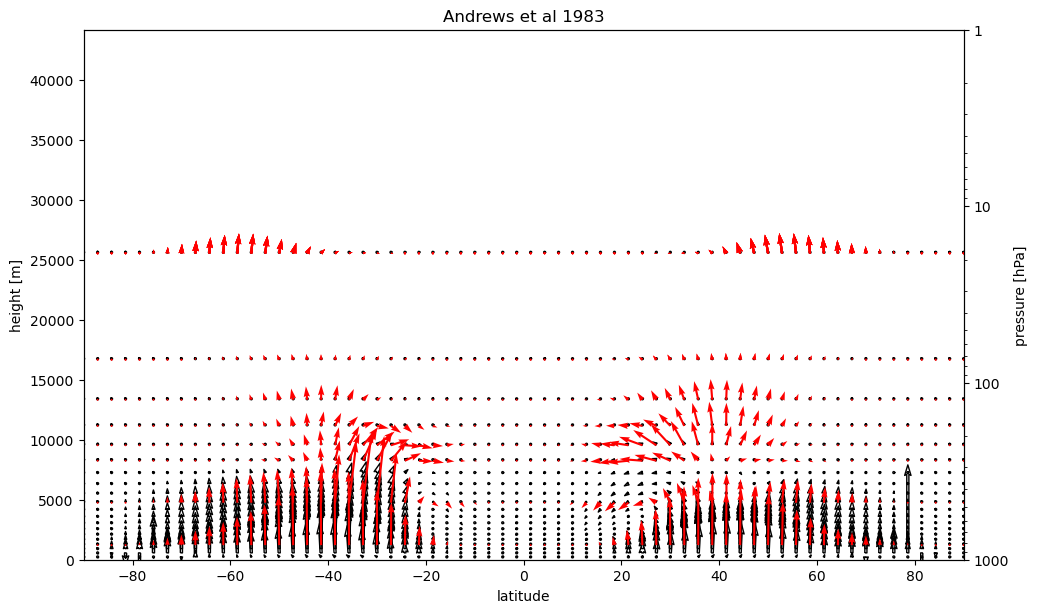

In [40]:
Fx = {}
Fy = {}
method = 'Andrews'
# f1,f2,F_phi,F_p = ReadERA(slice('1979-01-05','1979-03-03'),pskip=1)
pres = np.array([850,500,300,200,150,100,70,50,30,20,10,7,5,2])[::-1]
# pres = F_p.sel(level=slice(1,850)).level
lat = F_phi.latitude
# pres = np.array([50,70,100,150,200,250,300,400,500,700,850])
fig,ax = plt.subplots()
set_size(8.8,5.3,ax)
# Reference method
Fx[method],Fy[method],z = Andrews(F_phi,F_p)
print(Fx[method].shape)
# _,_ = ac.PlotEPfluxArrows(
#     f1.latitude,
#     f1.level.sel(level=pres, method='nearest'),
#     f1.sel(level=pres, latitude=lat, method='nearest').mean(dim='time'),
#     f2.sel(level=pres, latitude=lat, method='nearest').mean(dim='time'),
#     fig, ax,
#     xlim=[0, 80], ylim=[1000, 50], yscale=scale
# )
if scale == 'log':
    ax.quiver(lat,z,-Fx[method].mean(dim="time").T,-Fy[method].mean(dim="time").T,scale=2e9,**quiv_args)
    # Jucker (2020) method
    _,_,axp = ac.PlotEPfluxArrows(f1.sel(latitude=lat).latitude,
                                  f1.level.sel(level=pres, method='nearest'),
                                  -f1.sel(latitude=lat,level=pres, method='nearest').mean(dim='time'),
                                  -f2.sel(latitude=lat,level=pres, method='nearest').mean(dim='time'),
                                  fig,ax,
                                  xlim=[-90,90],ylim=[1000,1],yscale=scale,newax=True,scale=3e15)
    axp.get_children()[0].set_facecolor('r')
    axp.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0,6.4e3*np.log(1000))
    ax.set_ylabel('height [m]')
else:
    ax.quiver(lat,pres,Fx[method],Fy[method],scale=3e9,**quiv_args)
    # Jucker (2020) method
    _,_ = ac.PlotEPfluxArrows(f1.sel(latitude=lat).latitude,f1.sel(level=pres).level,f1.sel(latitude=lat,level=pres),f2.sel(latitude=lat,level=pres),fig,ax,xlim=[-90,90],ylim=[1000,1],yscale=scale,newax=False,scale=1e15)
    ax.get_children()[1].set_facecolor('r')
plt.title('Andrews et al 1983')
ax.set_xlabel('latitude')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
		# fig.savefig('figures/Andrews83.{0}.pdf'.format(scale),bbox_inches='tight')


In [41]:
import h5py
import numpy as np
import xarray as xr
import sys
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
import aostools_functions as ac

# --- Step 1: 資料讀取 ---
def load_hdf5_variable(file_path, var, start_idx, end_idx):
    print(f"Reading variable '{var}' from {file_path}...")
    with h5py.File(file_path, "r") as ds:
        data = np.asarray(ds[var][start_idx:end_idx])
    print(f"Done reading '{var}'. Shape = {data.shape}")
    return data

# --- Step 2: 計算 EP flux ---
def compute_ep_flux(u, v, t, p, lat):
    print("Computing zonal mean pressure...")
    p_1d = p.mean(axis=(0, 2, 3))

    print("Running EP flux computation (Jucker method)...")
    ep1, ep2, div1, div2 = ac.ComputeEPfluxDiv(lat, p_1d / 100, u, v, t)

    print("Wrapping results into xarray DataArrays...")
    time_len = u.shape[0]
    time_coord = np.arange(time_len)
    level_vals = np.round(p_1d / 100, 1)

    f1 = xr.DataArray(ep1, dims=["time", "level", "latitude"],
                      coords={"time": time_coord, "level": level_vals, "latitude": lat}, name='f1')
    f2 = xr.DataArray(ep2, dims=["time", "level", "latitude"],
                      coords={"time": time_coord, "level": level_vals, "latitude": lat}, name='f2')

    print("EP flux computation finished.\n")
    return f1, f2


In [42]:
# 設定 PR 實驗與資料區間
PR = 10
start_idx = 50000
end_idx = 70000
lat = np.linspace(90, -90, 64)

# 設定資料夾
base_dir = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}"

# 載入資料（含進度顯示）
u = load_hdf5_variable(f"{base_dir}/u/PR{PR}_500_20000day_6hourly_u.dat", "u", start_idx, end_idx)
v = load_hdf5_variable(f"{base_dir}/v/PR{PR}_500_20000day_6hourly_v.dat", "v", start_idx, end_idx)
t = load_hdf5_variable(f"{base_dir}/t/PR{PR}_500_20000day_6hourly_t.dat", "t", start_idx, end_idx)
p = load_hdf5_variable(f"{base_dir}/p/PR{PR}_500_20000day_6hourly_p.dat", "p", start_idx, end_idx)




Reading variable 'u' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR10/u/PR10_500_20000day_6hourly_u.dat...
Done reading 'u'. Shape = (20000, 20, 64, 128)
Reading variable 'v' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR10/v/PR10_500_20000day_6hourly_v.dat...
Done reading 'v'. Shape = (20000, 20, 64, 128)
Reading variable 't' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR10/t/PR10_500_20000day_6hourly_t.dat...
Done reading 't'. Shape = (20000, 20, 64, 128)
Reading variable 'p' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR10/p/PR10_500_20000day_6hourly_p.dat...
Done reading 'p'. Shape = (20000, 20, 64, 128)


In [43]:
# 計算 EP flux
f1, f2 = compute_ep_flux(u, v, t, p, lat)

Computing zonal mean pressure...
Running EP flux computation (Jucker method)...
Wrapping results into xarray DataArrays...
EP flux computation finished.



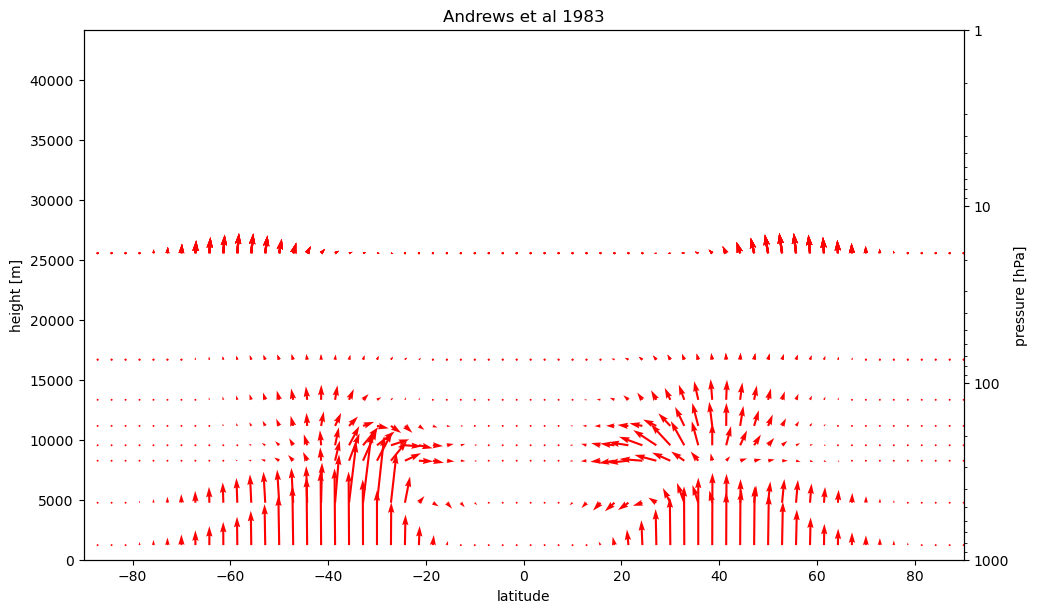

In [44]:
# f1,f2,F_phi,F_p = ReadERA(slice('1979-01-05','1979-03-03'),pskip=1)
pres = np.array([850,500,300,200,150,100,70,50,30,20,10,7,5,2])[::-1]
# pres = F_p.sel(level=slice(1,850)).level
lat = F_phi.latitude
# pres = np.array([50,70,100,150,200,250,300,400,500,700,850])
fig,ax = plt.subplots()
set_size(8.8,5.3,ax)
# Reference method
scale = "log"
if scale == 'log':
    # ax.quiver(lat,z,-Fx[method].mean(dim="time").T,-Fy[method].mean(dim="time").T,scale=2e9,**quiv_args)
    # Jucker (2020) method
    _,_,axp = ac.PlotEPfluxArrows(f1.sel(latitude=lat).latitude,
                                  f1.level.sel(level=pres, method='nearest'),
                                  -f1.sel(latitude=lat,level=pres, method='nearest').mean(dim='time'),
                                  -f2.sel(latitude=lat,level=pres, method='nearest').mean(dim='time'),
                                  fig,ax,
                                  xlim=[-90,90],ylim=[1000,1],yscale=scale,newax=True,scale=3e15)
    axp.get_children()[0].set_facecolor('r')
    axp.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0,6.4e3*np.log(1000))
    ax.set_ylabel('height [m]')

plt.title('Andrews et al 1983')
ax.set_xlabel('latitude')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
		# fig.savefig('figures/Andrews83.{0}.pdf'.format(scale),bbox_inches='tight')


In [68]:
PR = 0
time_idx_array_positive = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_positive_PR_{PR}.npy")
time_idx_array_negative = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_negative_PR_{PR}.npy")

In [69]:
time_idx_array_positive

array([ 1090,  1091,  1092, ..., 77560, 77561, 77562])

In [45]:
import h5py
import numpy as np
import xarray as xr
import sys
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
import aostools_functions as ac

def load_hdf5_variable(file_path, var, start_idx, end_idx):
    print(f"Reading variable '{var}' from {file_path}...")
    with h5py.File(file_path, "r") as ds:
        data = np.asarray(ds[var][start_idx:end_idx])
    print(f"Done reading '{var}'. Shape = {data.shape}")
    return data

def compute_ep_flux(u, v, t, p, lat):
    p_1d = p.mean(axis=(0, 2, 3))

    print("Running EP flux computation (Jucker method)...")
    ep1, ep2, div1, div2 = ac.ComputeEPfluxDiv(lat, p_1d / 100, u, v, t)

    print("Wrapping results into xarray DataArrays...")
    time_len = u.shape[0]
    time_coord = np.arange(time_len)
    level_vals = np.round(p_1d / 100, 1)

    f1 = xr.DataArray(ep1, dims=["time", "level", "latitude"],
                      coords={"time": time_coord, "level": level_vals, "latitude": lat}, name='f1')
    f2 = xr.DataArray(ep2, dims=["time", "level", "latitude"],
                      coords={"time": time_coord, "level": level_vals, "latitude": lat}, name='f2')

    print("EP flux computation finished.\n")
    return f1, f2

def process_PR_case(pr, lat, start_idx=50000, end_idx=70000):
    base_dir = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{pr}"
    print(f"\n========== Start processing PR = {pr} ==========")
    u = load_hdf5_variable(f"{base_dir}/u/PR{pr}_500_20000day_6hourly_u.dat", "u", start_idx, end_idx)
    v = load_hdf5_variable(f"{base_dir}/v/PR{pr}_500_20000day_6hourly_v.dat", "v", start_idx, end_idx)
    t = load_hdf5_variable(f"{base_dir}/t/PR{pr}_500_20000day_6hourly_t.dat", "t", start_idx, end_idx)
    p = load_hdf5_variable(f"{base_dir}/p/PR{pr}_500_20000day_6hourly_p.dat", "p", start_idx, end_idx)

    return compute_ep_flux(u, v, t, p, lat)

# 設定緯度與時間範圍
lat = np.linspace(90, -90, 64)
start_idx = 50000
end_idx = 70000

# PR=0 baseline
F_phi_base, F_p_base = process_PR_case(pr=0, lat=lat, start_idx=start_idx, end_idx=end_idx)

# 要比較的實驗 PR 值
PR_list = range(10, 20, 10)

# 儲存差異結果
diffs = {}

for pr in PR_list:
    F_phi_cmp, F_p_cmp = process_PR_case(pr=pr, lat=lat, start_idx=start_idx, end_idx=end_idx)

    # 內插至 PR=0 的 pressure level，以避免 shape mismatch
    F_phi_cmp_interp = F_phi_cmp.interp(level=F_phi_base.level, method="nearest")
    F_p_cmp_interp   = F_p_cmp.interp(level=F_p_base.level,   method="nearest")

    diff_phi = F_phi_cmp_interp - F_phi_base
    diff_p   = F_p_cmp_interp   - F_p_base

    diffs[pr] = (diff_phi, diff_p)

    print(f"✓ PR={pr} vs PR=0 difference computed.\n{'-'*40}")



========== Start processing PR = 0 ==========
Reading variable 'u' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/u/PR0_500_20000day_6hourly_u.dat...
Done reading 'u'. Shape = (20000, 20, 64, 128)
Reading variable 'v' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/v/PR0_500_20000day_6hourly_v.dat...
Done reading 'v'. Shape = (20000, 20, 64, 128)
Reading variable 't' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/t/PR0_500_20000day_6hourly_t.dat...
Done reading 't'. Shape = (20000, 20, 64, 128)
Reading variable 'p' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/p/PR0_500_20000day_6hourly_p.dat...
Done reading 'p'. Shape = (20000, 20, 64, 128)
Running EP flux computation (Jucker method)...
Wrapping results into xarray DataArrays...
EP flux

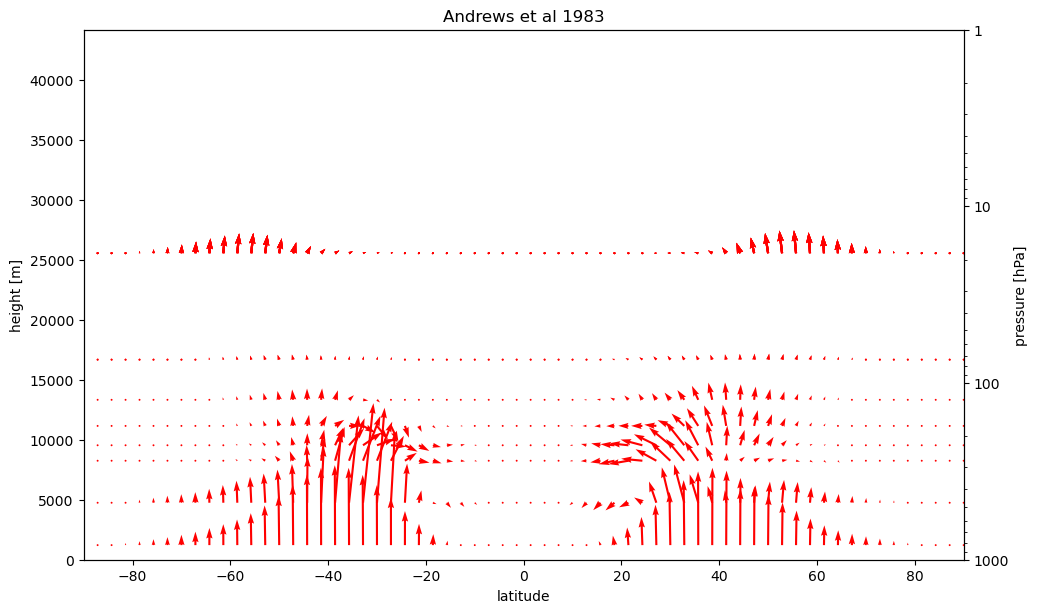

In [65]:
# f1,f2,F_phi,F_p = ReadERA(slice('1979-01-05','1979-03-03'),pskip=1)
pres = np.array([850,500,300,200,150,100,70,50,30,20,10,7,5,2])[::-1]
# pres = F_p.sel(level=slice(1,850)).level
lat = F_phi_base.latitude
# pres = np.array([50,70,100,150,200,250,300,400,500,700,850])
fig,ax = plt.subplots()
set_size(8.8,5.3,ax)
# Reference method
scale = "log"
if scale == 'log':
    # ax.quiver(lat,z,-Fx[method].mean(dim="time").T,-Fy[method].mean(dim="time").T,scale=2e9,**quiv_args)
    # Jucker (2020) method
    _,_,axp = ac.PlotEPfluxArrows(F_phi_cmp_interp.sel(latitude=lat).latitude,
                                  F_phi_cmp_interp.level.sel(level=pres, method='nearest'),
                                  -F_phi_cmp_interp.sel(latitude=lat,level=pres, method='nearest').mean(dim='time') - (-F_phi_base.sel(latitude=lat,level=pres, method='nearest').mean(dim='time')),
                                  -F_p_cmp_interp.sel(latitude=lat,level=pres, method='nearest').mean(dim='time') - (-F_p_base.sel(latitude=lat,level=pres, method='nearest').mean(dim='time')),
                                  fig,ax,
                                  xlim=[-90,90],ylim=[1000,1],yscale=scale,newax=True,scale=3e15)
    axp.get_children()[0].set_facecolor('r')
    axp.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0,6.4e3*np.log(1000))
    ax.set_ylabel('height [m]')

plt.title('Andrews et al 1983')
ax.set_xlabel('latitude')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
		# fig.savefig('figures/Andrews83.{0}.pdf'.format(scale),bbox_inches='tight')


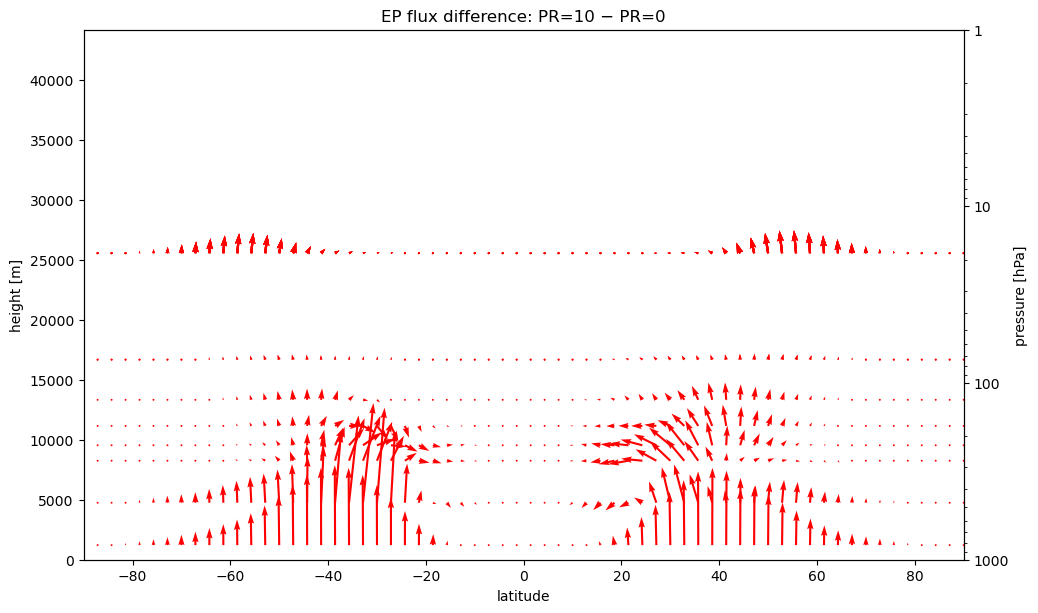

In [66]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

pres = np.array([850, 500, 300, 200, 150, 100, 70, 50, 30, 20, 10, 7, 5, 2])[::-1]
lat = diffs[10][0].latitude  # 或 f1.latitude

fig, ax = plt.subplots()
set_size(8.8, 5.3, ax)
scale = "log"

# 取出差值資料
ep1_diff = diffs[10][0].sel(latitude=lat, level=pres, method='nearest').mean(dim='time')
ep2_diff = diffs[10][1].sel(latitude=lat, level=pres, method='nearest').mean(dim='time')

# 確保維度對齊（展平）
yy, xx = xr.broadcast(ep1_diff.level, ep1_diff.latitude)




if scale == 'log':
    _, _, axp = ac.PlotEPfluxArrows(
        xx.values, yy.values,
        -ep1_diff.values, -ep2_diff.values,
        fig, ax,
        xlim=[-90, 90],
        ylim=[1000, 1],
        yscale='log',
        newax=True,
        scale=3e15
    )
    axp.get_children()[0].set_facecolor('r')
    axp.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0, 6.4e3 * np.log(1000))
    ax.set_ylabel('height [m]')

plt.title('EP flux difference: PR=10 − PR=0')
ax.set_xlabel('latitude')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())


## Test PC1 > std and < std time index 

In [ ]:
import numpy as np
import xarray as xr
import h5py

# Constants
lat = np.linspace(90, -90, 64)
lags_5_20 = range(15 * 4, 15 * 4+1, 1)  # lags 15–25 days
lags_30_60 = range(90 * 4, 90 * 4+1, 1)  # lags 90–100 days
PR_list = [0, 10]

# Load all variables only once per PR
def load_all_variables(pr):
    base_dir = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{pr}"
    def load_var(var):
        with h5py.File(f"{base_dir}/{var}/PR{pr}_500_20000day_6hourly_{var}.dat", "r") as ds:
            return np.asarray(ds[var][:])
    return {
        "u": load_var("u"),
        "v": load_var("v"),
        "t": load_var("t"),
        "p": load_var("p"),
    }

# Wrapper to compute EP flux using provided arrays
def compute_ep_flux(u, v, t, p, lat):
    import sys
    sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
    import aostools_functions as ac
    p_1d = p.mean(axis=(0, 2, 3))
    ep1, ep2  = ac.ComputeEPfluxDiv(lat, p_1d / 100, u, v, t)
    level_vals = np.round(p_1d / 100, 1)
    return xr.DataArray(ep1, dims=["time", "level", "latitude"],
                        coords={"time": np.arange(u.shape[0]), "level": level_vals, "latitude": lat}), \
           xr.DataArray(ep2, dims=["time", "level", "latitude"],
                        coords={"time": np.arange(u.shape[0]), "level": level_vals, "latitude": lat})

# Composite EP flux for a specific PR
def composite_ep_flux(data, time_idx_array, lags):
    f1_all, f2_all = [], []
    u, v, t, p = data["u"], data["v"], data["t"], data["p"]
    for lag in lags:
        valid_idx = time_idx_array + lag
        valid_idx = valid_idx[(valid_idx >= 0) & (valid_idx < u.shape[0])]
        if len(valid_idx) == 0:
            continue
        f1, f2 = compute_ep_flux(u[valid_idx], v[valid_idx], t[valid_idx], p[valid_idx], lat)
        f1_all.append(f1.mean("time"))
        f2_all.append(f2.mean("time"))
    return xr.concat(f1_all, dim="lag").mean("lag"), xr.concat(f2_all, dim="lag").mean("lag")

# Storage
same_pr_ep_diff = {}
final_diff_vs_pr0 = {}

for pr in PR_list:
    print(f"Loading data for PR={pr}...")
    data = load_all_variables(pr)

    time_idx_pos = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_positive_PR_{pr}.npy")
    time_idx_neg = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_negative_PR_{pr}.npy")

    print(f"--> Computing EP+ composite for PR={pr}")
    ep1_pos, ep2_pos         = composite_ep_flux(data, time_idx_pos, lags_5_20)
    ep1_far_pos, ep2_far_pos = composite_ep_flux(data, time_idx_pos, lags_30_60)
    
    # interpolate to ep1_far_pos.level
    ep1_pos_interp = ep1_pos.interp(level=ep1_far_pos.level, method="nearest")
    ep2_pos_interp = ep2_pos.interp(level=ep2_far_pos.level, method="nearest")
    
    EP_plus   = ep1_pos_interp - ep1_far_pos
    EP_plus_p = ep2_pos_interp - ep2_far_pos
    print(ep1_pos_interp.shape, ep1_far_pos.shape, EP_plus.shape)

    print(f"--> Computing EP- composite for PR={pr}")
    ep1_neg, ep2_neg         = composite_ep_flux(data, time_idx_neg, lags_5_20)
    ep1_far_neg, ep2_far_neg = composite_ep_flux(data, time_idx_neg, lags_30_60)

    # interpolate to ep1_far_pos.level
    ep1_neg_interp = ep1_neg.interp(level=ep1_far_neg.level, method="nearest")
    ep2_neg_interp = ep2_neg.interp(level=ep2_far_neg.level, method="nearest")
    
    EP_minus   = ep1_neg_interp - ep1_far_neg
    EP_minus_p = ep2_neg_interp - ep2_far_neg
 
    # interpolate to ep1_far_pos.level
    EP_plus_interp   = EP_plus.interp(level=EP_minus.level, method="nearest")
    EP_plus_p_interp = EP_plus_p.interp(level=EP_minus_p.level, method="nearest")
    
    diff_phi = EP_plus_interp - EP_minus
    diff_p   = EP_plus_p_interp - EP_minus_p
    print(diff_phi.shape, EP_plus_interp.shape, EP_minus.shape)
    same_pr_ep_diff[pr] = (diff_phi, diff_p)

    # === Save EP flux diff results ===
    save_path = "/data92/PeterChang/back_to_master1220/Moist_Dycore/same_pr_ep_diff.nc"
    print(f"\nSaving EP flux diff to {save_path}...")
    
    # 將所有 PR 的資料整理進 Dataset
    ds_out = xr.Dataset()
    for pr in same_pr_ep_diff:
        ds_out[f"EP_phi_diff_PR{pr}"] = same_pr_ep_diff[pr][0]
        ds_out[f"EP_p_diff_PR{pr}"]   = same_pr_ep_diff[pr][1]
    
    # 儲存為 NetCDF
    ds_out.to_netcdf(save_path)
    print("✓ Save complete.")




Loading data for PR=0...
--> Computing EP+ composite for PR=0


In [105]:
# # Difference from PR=0
# for pr in PR_list:
#     if pr == 0:
#         continue
#     diff_vs_pr0_phi = same_pr_ep_diff[pr][0].interp_like(same_pr_ep_diff[0][0]) - same_pr_ep_diff[0][0]
#     diff_vs_pr0_p   = same_pr_ep_diff[pr][1].interp_like(same_pr_ep_diff[0][1]) - same_pr_ep_diff[0][1]
#     final_diff_vs_pr0[pr] = (diff_vs_pr0_phi, diff_vs_pr0_p)

In [106]:
# # Read vars
# ds = xr.open_dataset("/data92/PeterChang/back_to_master1220/Moist_Dycore/same_pr_ep_diff.nc")
# diff_phi_pr10 = ds["EP_phi_diff_PR10"]
# diff_p_pr10   = ds["EP_p_diff_PR10"]



In [114]:
# final_diff_vs_pr0

{10: (<xarray.DataArray (level: 20, latitude: 64)>
  array([[-3.8516947 , -3.23973083, -2.6589179 , ..., -0.99085236,
          -0.45372963,  0.06197524],
         [-1.93421799, -1.50063115, -1.1260221 , ...,  0.12778568,
           0.20422363,  0.09035873],
         [-1.30833197, -1.09333616, -0.96419317, ...,  0.23661375,
          -0.01366401, -0.48415327],
         ...,
         [-0.12254799, -0.15582364, -0.28727569, ...,  0.4062733 ,
           0.11694629, -0.45112983],
         [-0.08480896, -0.13370002, -0.28826914, ...,  0.42214258,
           0.12026978, -0.5048875 ],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan]])
  Coordinates:
    * latitude  (latitude) float64 90.0 87.14 84.29 81.43 ... -84.29 -87.14 -90.0
    * level     (level) float32 18.4 73.7 124.4 174.7 ... 826.3 876.4 926.5 976.6,
  <xarray.DataArray (level: 20, latitude: 64)>
  array([[-2.37349350e-05, -5.24656825e-05, -7.94330759e-05, ...,
           3.0293

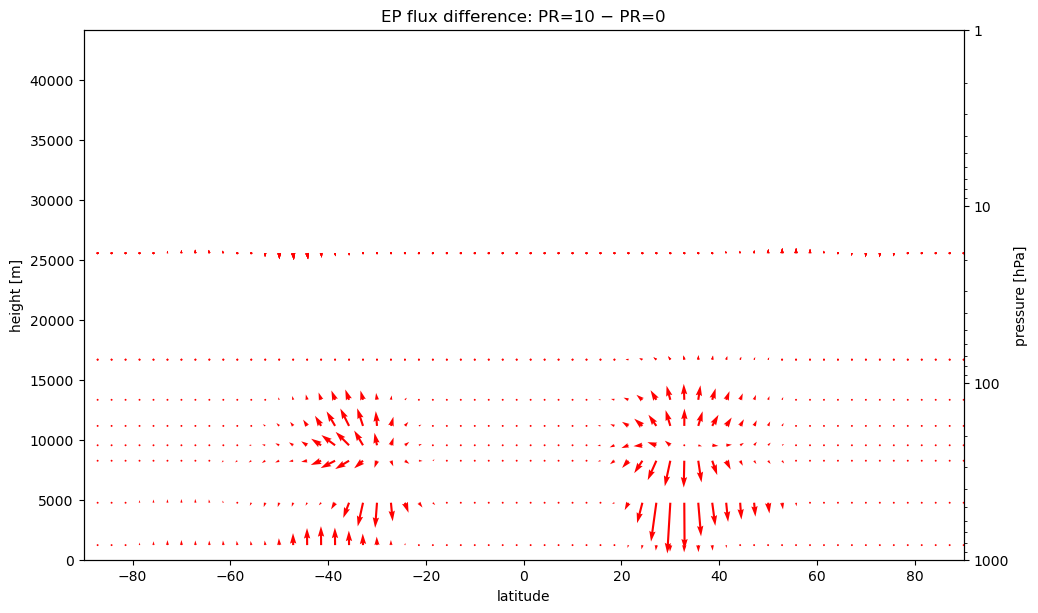

In [115]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import sys
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
import aostools_functions as ac

pres = np.array([850, 500, 300, 200, 150, 100, 70, 50, 30, 20, 10, 7, 5, 2])[::-1]
lat = same_pr_ep_diff[10][0].latitude  # 或 f1.latitude

fig, ax = plt.subplots()
set_size(8.8, 5.3, ax)
scale = "log"

# 取出差值資料
ep1_diff = same_pr_ep_diff[10][0].sel(latitude=lat, level=pres, method='nearest')
ep2_diff = same_pr_ep_diff[10][1].sel(latitude=lat, level=pres, method='nearest')
# 確保維度對齊（展平）
yy, xx = xr.broadcast(ep1_diff.level, ep1_diff.latitude)

if scale == 'log':
    _, _, axp = ac.PlotEPfluxArrows(
        xx.values, yy.values,
        -ep1_diff.values, -ep2_diff.values,
        fig, ax,
        xlim=[-90, 90],
        ylim=[1000, 1],
        yscale='log',
        newax=True,
        scale=3e15
    )
    axp.get_children()[0].set_facecolor('r')
    axp.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0, 6.4e3 * np.log(1000))
    ax.set_ylabel('height [m]')

plt.title('EP flux difference: PR=10 − PR=0')
ax.set_xlabel('latitude')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())


In [43]:
ep1_diff.values.min()

-1.1920928999487046e-07

In [49]:
ep2_diff.values.max()

2.220446049250313e-16

# Check $N^2$

In [74]:
# Function to read data from HDF5
def Read_var_simple(var, PR):
    str_var = str(var)
    common_path = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/"
    last_path = f"PR{PR}/{str_var}/PR{PR}_500_20000day_6hourly_{str_var}_zonal_mean.dat"
    with h5py.File(common_path + last_path, 'r') as file:
        data = np.asarray(file[str_var][:])
    return data

In [80]:
N_square_all = np.zeros((6, 78000, 20, 64))
i = 0
g = 9.81
# Read zonal mean variables
for PR in range(0, 60, 10):
    theta_zonal_mean_all = Read_var_simple("theta", PR)
    dtheta_all           = Read_var_simple("dtheta", PR)
    dz_all               = Read_var_simple("dz", PR)
    # v_prime_b_prime_all  = Read_var_simple("v_prime_b_prime", PR)
    # EMF_all              = Read_var_simple("EMF", PR)
    
    # Calculate N squared
    dthetadz_all = dtheta_all / dz_all
    N_square_all[i] = g / theta_zonal_mean_all * dthetadz_all
    i += 1

KeyboardInterrupt: 

In [77]:
N_square_all.shape

(6, 78000, 20, 64)

In [146]:
def plot_contourf_near0_fixcolorbar_fig2_3(X, Y ,var_near0, axs, cbar_lim, shading_levels = 9, least_levels = 4, near0white = True, my_cmap = 'coolwarm'):
    from matplotlib.colors import ListedColormap
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import TwoSlopeNorm
    #####
    import matplotlib.colors as colors
    # a, antialiased = 0.6, True
#     a, antialiased = 0.7, True
    a, antialiased = 0.9, True
    # a, antialiased = 1, False
    
    my_cmap = plt.colormaps[my_cmap]  
    
    # create random data with cbar_lim
    rngdata = np.random.uniform(low=cbar_lim[0], high=cbar_lim[1], size=(len(Y),len(X)))
    
    # make sure the min and Max value are included
    rngdata[0,0] = cbar_lim[0]
    rngdata[-1,-1] = cbar_lim[1]

    # get contour levels with random data
    cs = axs.contourf(X, Y, rngdata, levels = 11, norm=TwoSlopeNorm(0), cmap=my_cmap, alpha = a, antialiased = antialiased)
    auto_levels_rng = cs.levels.copy()
    plt.gca().clear()
    
    cs = axs.contourf(X, Y, var_near0, levels = auto_levels_rng, norm=TwoSlopeNorm(0), cmap=my_cmap, alpha = a, antialiased = antialiased)
    auto_levels2 = cs.levels.copy()
    # cbar = add_colorbar(cs)#plt.colorbar()
    #plt.show()

    if ~((np.min(auto_levels2) >= 0) | (np.max(auto_levels2) <= 0)):
        plt.gca().clear()
        
        try:
            cbar.remove()
        except:
            pass
        
        # check levels of both ends
        # if either end has contour levels less than 'least_levels', create custom levels
        if ((len(np.where(auto_levels2 > 0)[0]) < least_levels) | (len(np.where(auto_levels2 < 0)[0]) < least_levels)):
            cs = plt.contourf(X,Y,var_near0, norm=TwoSlopeNorm(0), levels = np.linspace(auto_levels_rng.min(), auto_levels_rng.max(), 100))
            auto_levels1 = cs.levels.copy()
        #     plt.colorbar()
        #     plt.show()
            plt.gca().clear()
            if (len(np.where(auto_levels2 > 0)[0]) > len(np.where(auto_levels2 < 0)[0])):
                   custom_levels = np.concatenate((np.linspace(np.min(auto_levels1), 0, least_levels+1), 
                                    auto_levels2[auto_levels2 > 0]))

            else:
                   custom_levels = np.concatenate((auto_levels2[auto_levels2 < 0], 
                                               np.linspace(0,np.max(auto_levels1),least_levels+1)))

            #custom_levels = np.unique(custom_levels)
            custom_levels_bar = custom_levels
        else:

            custom_levels = auto_levels2
            custom_levels_bar = custom_levels

        # create white shading around 0
        if near0white:
            custom_lower = custom_levels[custom_levels < 0]
            dlevel_lower = custom_lower[1] - custom_lower[0]
            custom_lower_near0 = np.concatenate((custom_lower, [0 - dlevel_lower/5]))

            custom_upper = custom_levels[custom_levels > 0]
            dlevel_upper = custom_upper[1] - custom_upper[0]
            custom_upper_near0 = np.concatenate(([dlevel_upper/5 - 0] ,custom_upper))

            custom_levels_near0 = np.concatenate((custom_lower_near0, [0], custom_upper_near0))

            mycmap_lower_near0 = my_cmap(np.linspace(0, 0.5, len(custom_levels_near0[custom_levels_near0 < 0])))
            mycmap_upper_near0 = my_cmap(np.linspace(0.5, 1, len(custom_levels_near0[custom_levels_near0 >= 0])))[1:]
            all_colors = np.vstack((mycmap_lower_near0, mycmap_upper_near0))

            all_colors[np.where(custom_levels_near0 == 0)[0]] = [1, 1, 1, 1] # set to white
            all_colors[np.where(custom_levels_near0 == 0)[0] - 1] = [1, 1, 1, 1]
            
#             all_colors[np.where(custom_levels_near0 == 0)[0]] = [0.85, 0.85, 0.85, 1] # set to gray
#             all_colors[np.where(custom_levels_near0 == 0)[0] - 1] = [0.85, 0.85, 0.85, 1]

            #all_colors[:,0:3] *= a


            mycmap_near0 = colors.LinearSegmentedColormap.from_list('mycmap_near0', all_colors)

            custom_levels = custom_levels_near0
            mycmap = mycmap_near0
        else:
            mycmap = my_cmap


        norm = colors.BoundaryNorm(boundaries=custom_levels, ncolors=256)

        cs = axs.contourf(X, Y, var_near0, levels = custom_levels, cmap=mycmap, norm=norm, alpha = a, antialiased = antialiased)
        # cbar = plt.colorbar(cs, spacing="proportional")
        # cbar = add_colorbar(cs, aspect=8, pad_fraction=0.8)#

#         cbar.set_ticks(custom_levels_bar)
#         ticklabs = cbar.ax.get_yticklabels()
#         cbar.ax.set_yticklabels(ticklabs, fontsize=14)

        # axs.title("$N^2$ difference between L = Dry", fontsize=14)
        # plt.xlabel("Latitude")
        # ax.set_ylabel("Sigma")
        axs.set_ylim([1,0])
        # plt.xlim([0,70])


        
    #####
    return custom_levels, custom_levels_bar, cs

L = Dry, N^2.min(): -6.124469657428794e-05
L = Dry, N^2.max(): 0.0006177863715981209


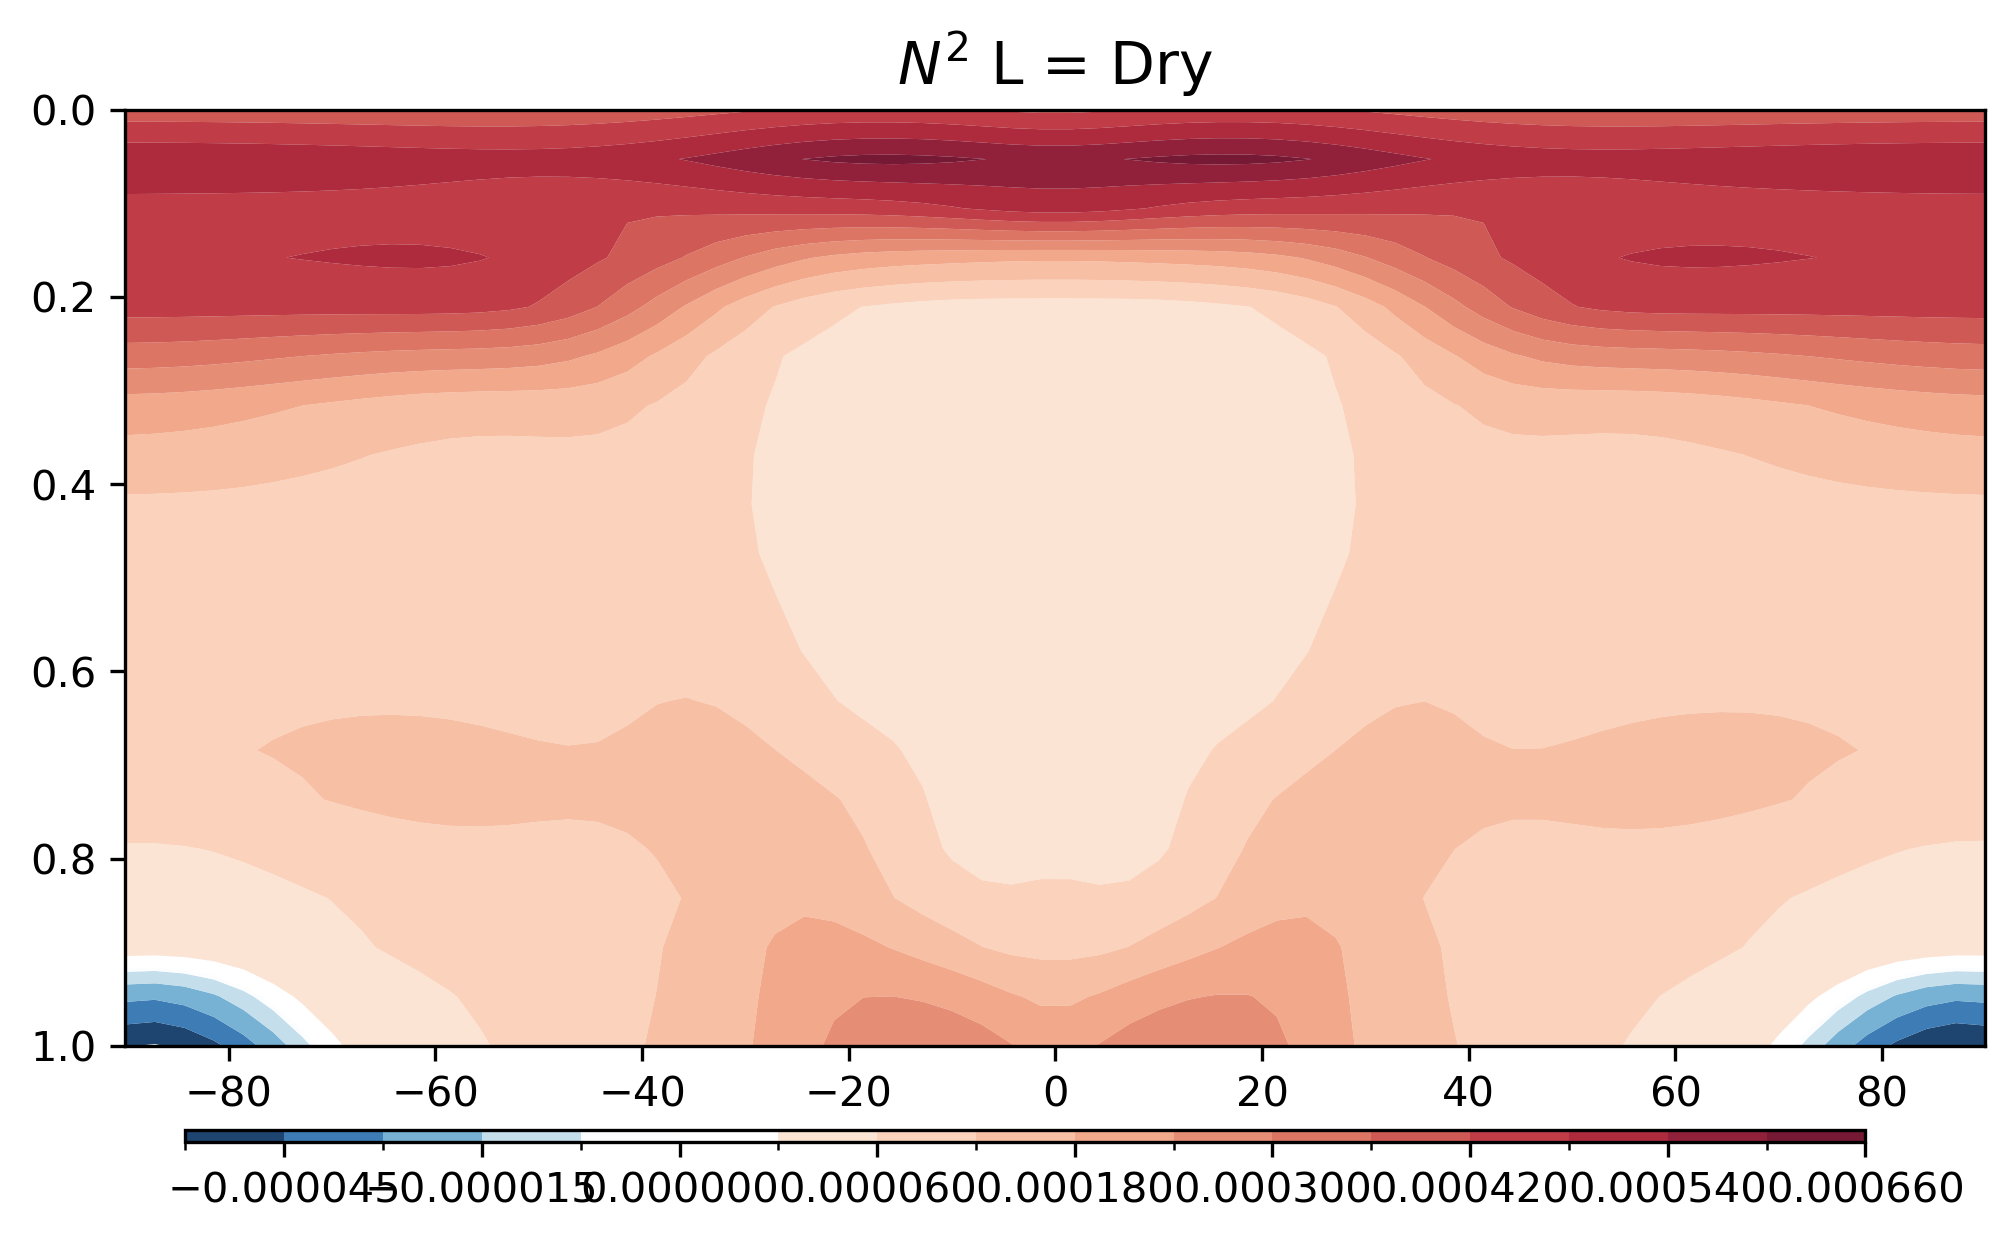

In [174]:
sigma = np.linspace(0,1,20)
y = np.linspace(-90,90,64)
fig, ax = plt.subplots(1, figsize=(8,4), dpi=300.)

# For storing cs to use for colorbar later
cs_for_colorbar = None

_, custom_levels_bar2, cs = plot_contourf_near0_fixcolorbar_fig2_3(
    y, sigma, N_square_all[0,5000*4:].mean(axis=0), ax, 
    cbar_lim=[-5E-5, 6.1E-4],
    my_cmap='RdBu_r'
)
plt.title("$N^2$ L = Dry", fontsize=14)
cs_for_colorbar = cs  # store the last cs

# Add a horizontal colorbar below the last axis
fig.subplots_adjust(bottom=0.1)  # adjust as needed
cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.01])  # [left, bottom, width, height]
fig.colorbar(cs_for_colorbar, cax=cbar_ax, orientation='horizontal')
print("L = Dry, N^2.min():", N_square_all[0,5000*4:].mean(axis=0).min())
print("L = Dry, N^2.max():", N_square_all[0,5000*4:].mean(axis=0).max())


-1.9842596768561763e-05
4.682385210088918e-05
-5.008153503806742e-05
7.510465274876275e-05
-8.391108011026761e-05
9.540901275533246e-05
-0.00010323475817430554
0.0001182973797827431
-0.00012576956493570132
0.00013776118802514737


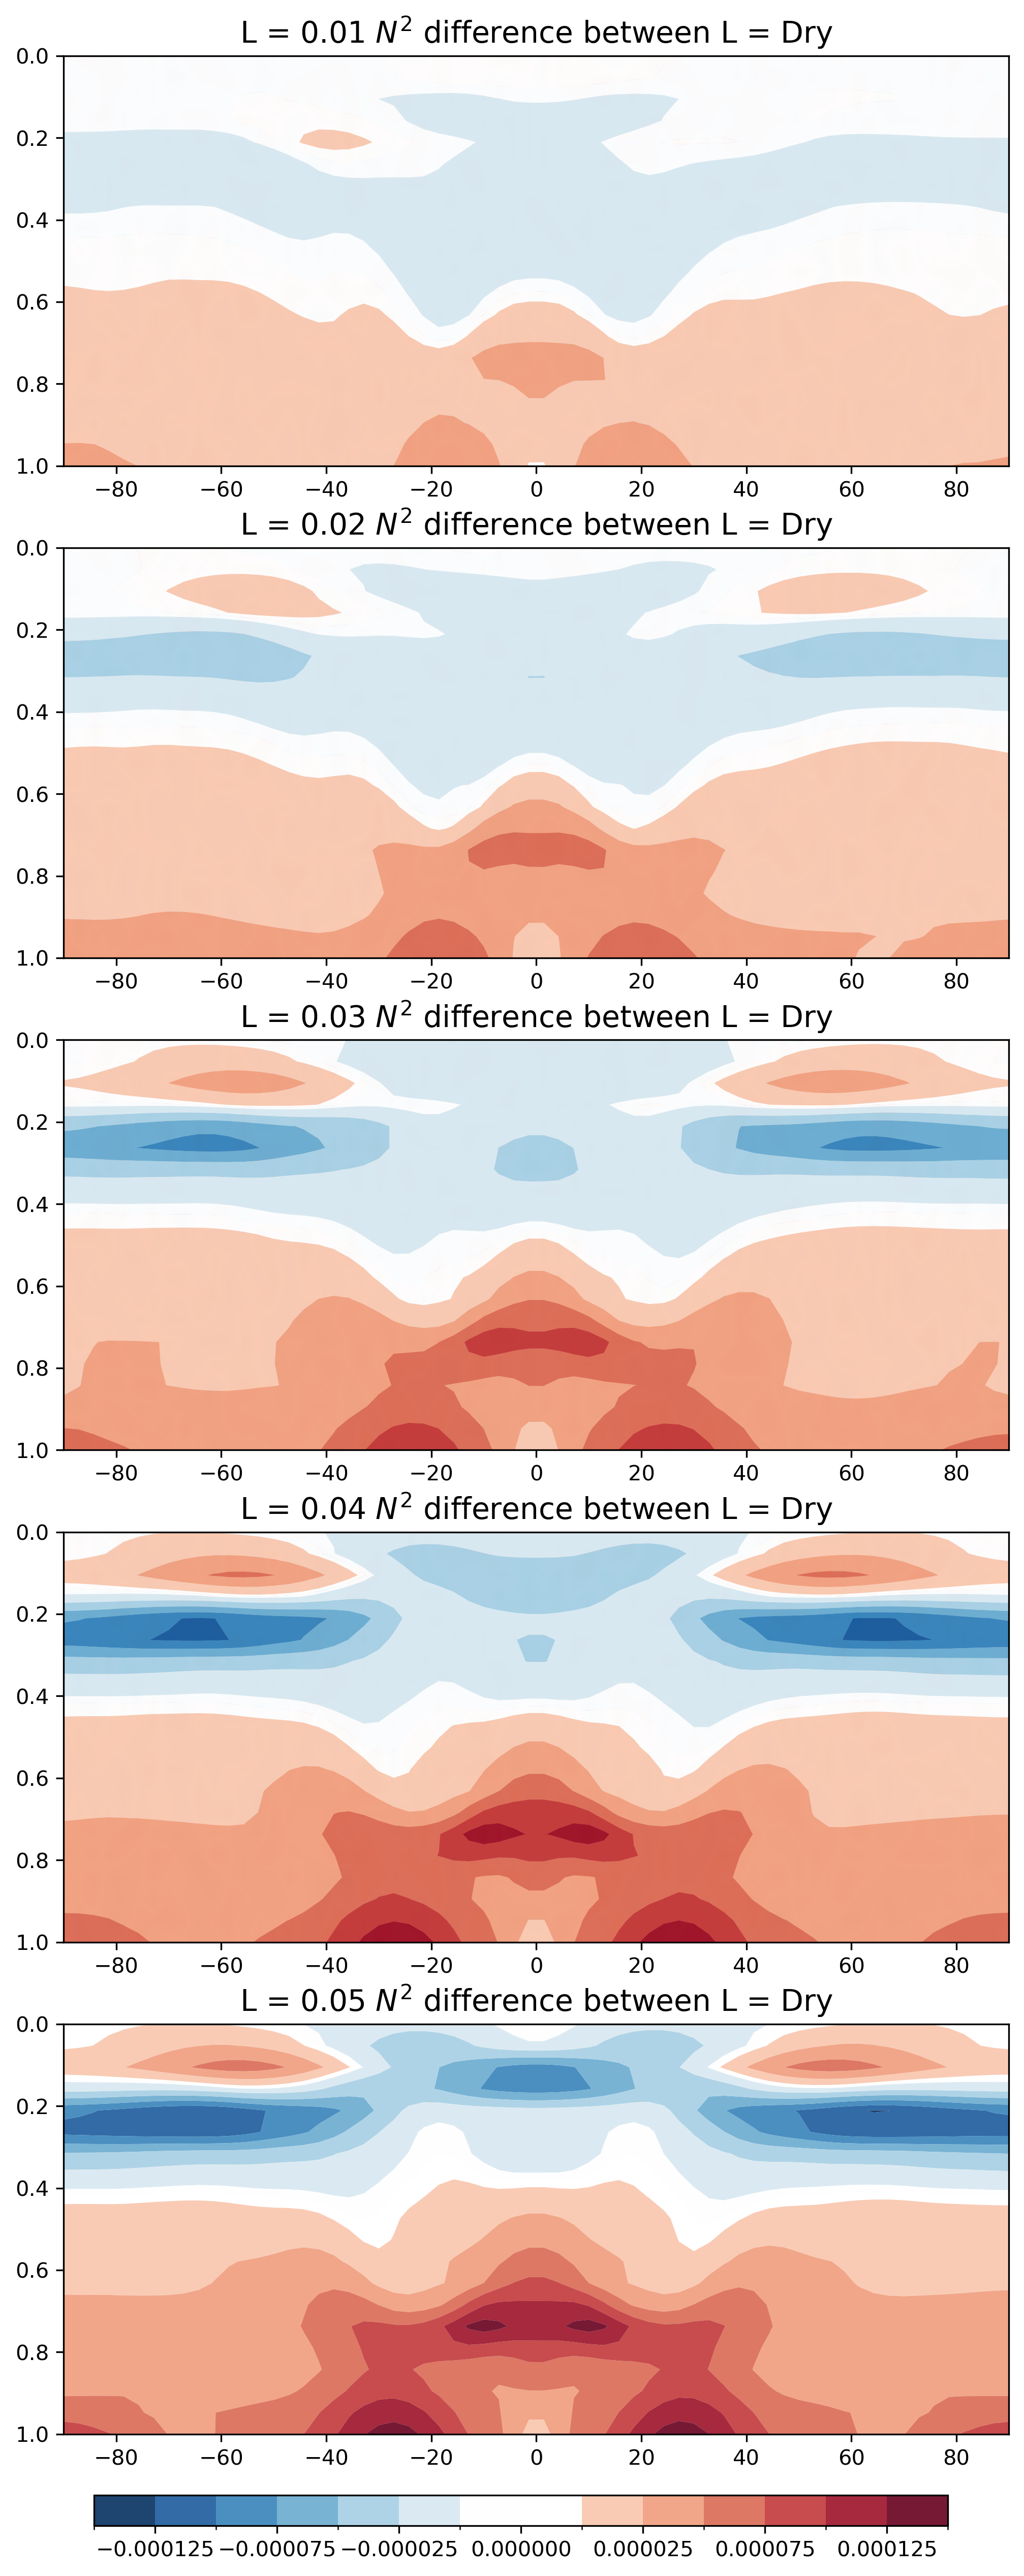

In [175]:
sigma = np.linspace(0,1,20)
y = np.linspace(-90,90,64)
fig, ax = plt.subplots(5, figsize=(8,20), dpi=300.)

# For storing cs to use for colorbar later
cs_for_colorbar = None

for i in range(5):
    N_square_diff = N_square_all[i+1,5000*4:].mean(axis=0) - N_square_all[0,5000*4:].mean(axis=0)
    _, custom_levels_bar2, cs = plot_contourf_near0_fixcolorbar_fig2_3(
        y, sigma, N_square_diff, ax[i], 
        cbar_lim=[-1.5E-4, 1.5E-4],
        my_cmap='RdBu_r'
    )
    ax[i].set_title(f"L = {(i+1)*0.01} $N^2$ difference between L = Dry", fontsize=14)
    cs_for_colorbar = cs  # store the last cs
    print(N_square_diff.min())
    print(N_square_diff.max())
    

# Add a horizontal colorbar below the last axis
fig.subplots_adjust(bottom=0.1)  # adjust as needed
cbar_ax = fig.add_axes([0.15, 0.07, 0.7, 0.01])  # [left, bottom, width, height]
fig.colorbar(cs_for_colorbar, cax=cbar_ax, orientation='horizontal')


In [44]:
# Constant
f0 = 2 * 7.29E-5 * np.sin(np.deg2rad(np.linspace(-90,90,64)))
g  = 9.81

In [52]:
ehf.shape

(400, 20, 64, 128)

In [59]:
# EP flux j and k component
F_j =  emf.mean(axis=(0,3)) # np.mean(EMF, axis=(0,3))
F_k = (f0[np.newaxis, np.newaxis, :] * ehf.mean(axis=3) / N_square_test_all).mean(axis=0)

In [60]:
F_j.shape

(20, 64)

(1.0, 0.0)

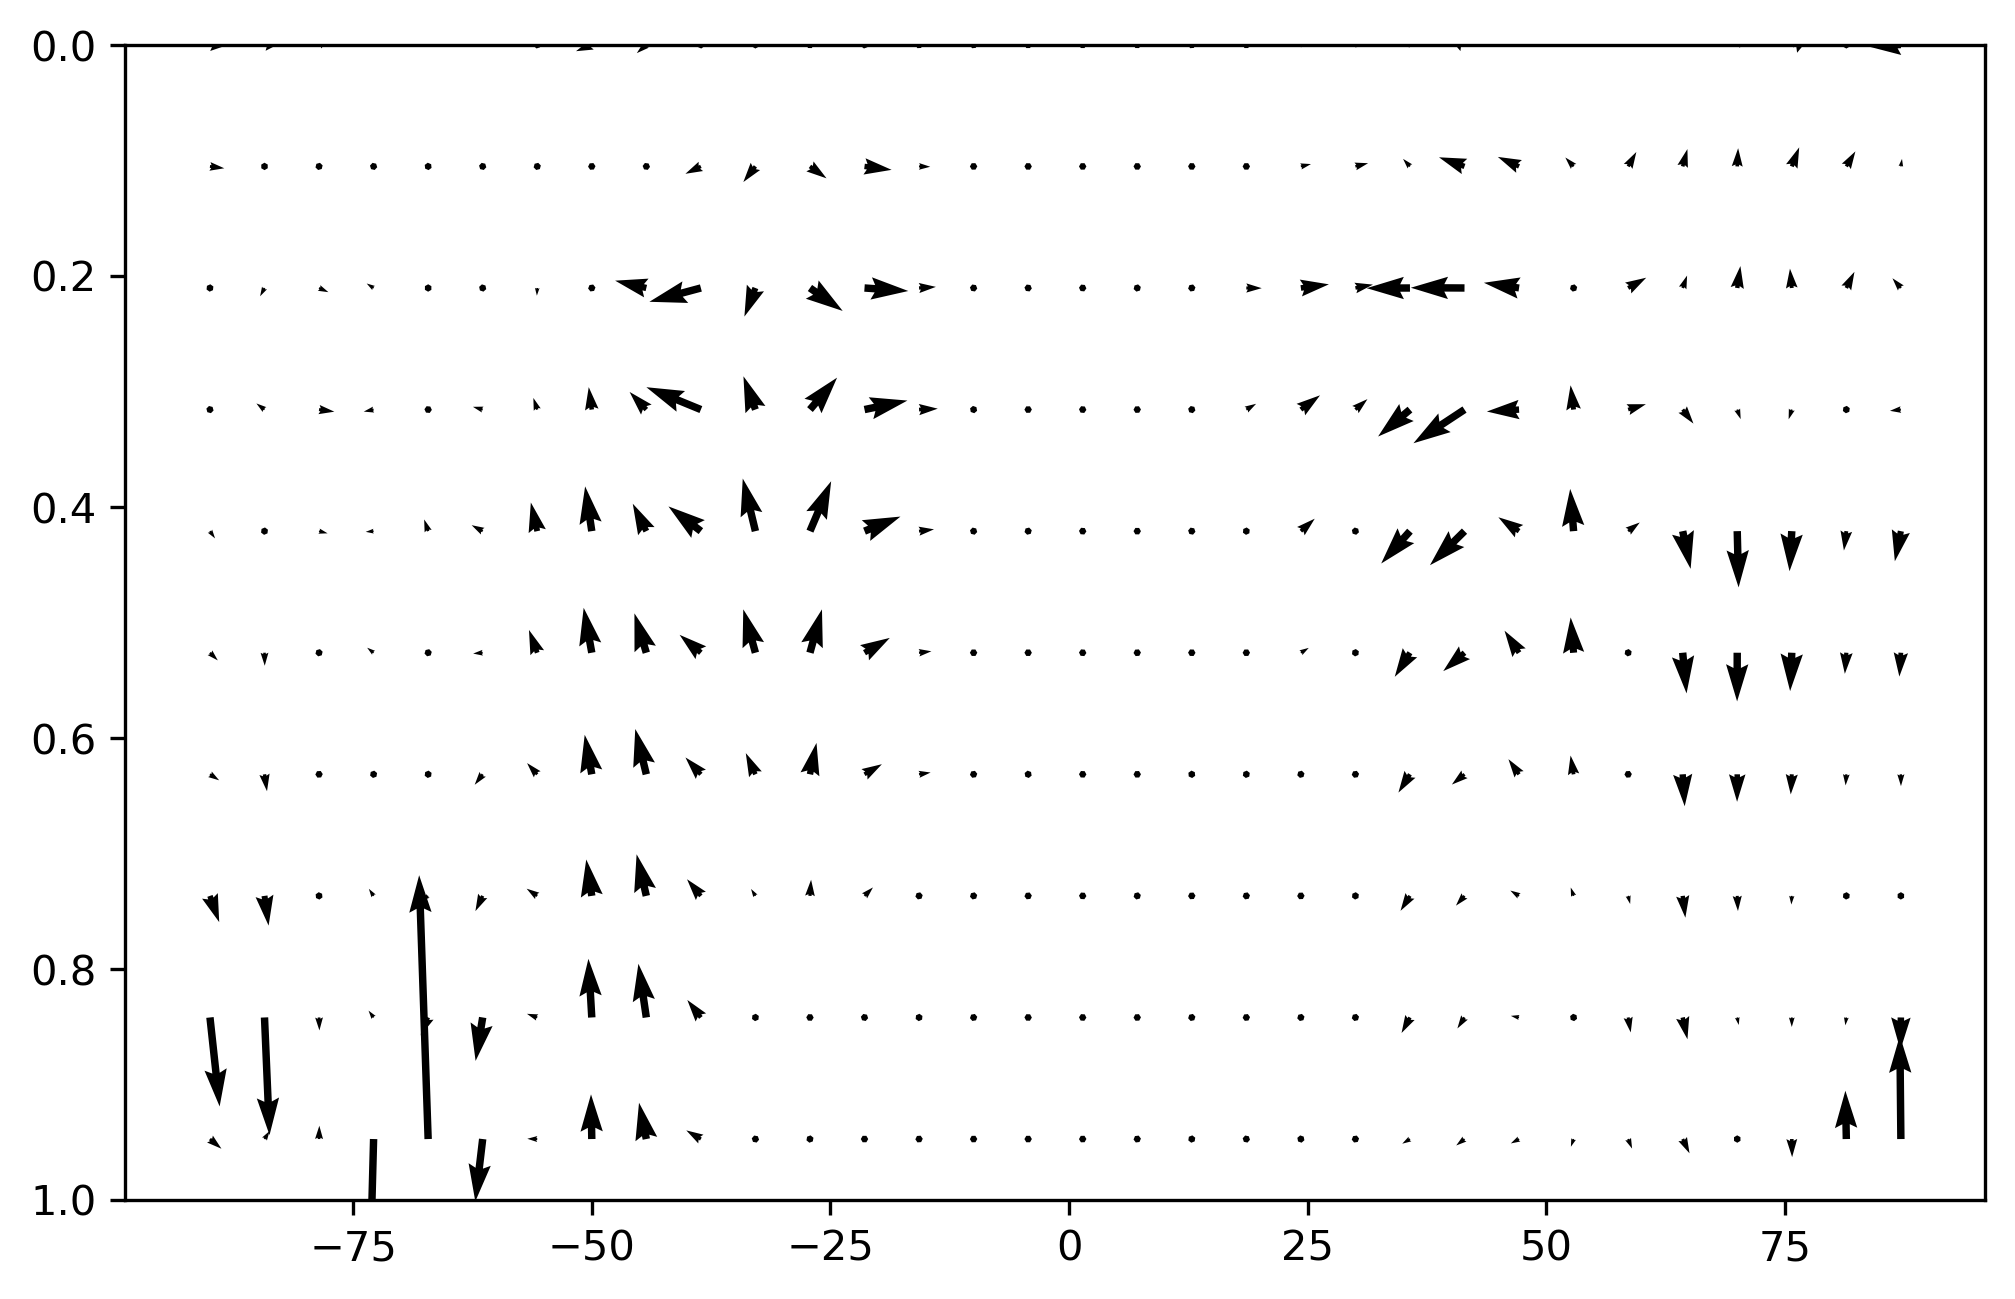

In [61]:
fig, ax = plt.subplots(1, figsize=(8, 5), dpi=300)
y = np.linspace(-90,90,64)
z = np.linspace(0,1,20)
yy, zz = np.meshgrid(y,z)
wind_plt = ax.quiver(yy[::2, ::2], zz[::2, ::2], -F_j[::2, ::2], F_k[::2, ::2],
          color="black", scale_units='xy', angles='xy', width=4e-3, scale=2)
plt.ylim([1,0])

# Cal EP flux again 05/22

In [81]:
PR = 0
time_idx_array_positive = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_positive_PR_{PR}.npy")
time_idx_array_negative = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_negative_PR_{PR}.npy")

In [254]:
time_idx_array_positive[:]

array([ 1090,  1091,  1092, ..., 77560, 77561, 77562])

## EMF and EHF

In [12]:
start_idx = 5000
end_idx   = 7000
adiag = AtmosphericDiagnostics(u[start_idx:end_idx], v[start_idx:end_idx], t[start_idx:end_idx], p[start_idx:end_idx], z[start_idx:end_idx])
emf_mean, ehf_mean = adiag.run_emf_ehf()
emf_mean.shape

EMF and EHF progress:
[########################################] | 100% Completed | 312.58 ms
[########################################] | 100% Completed | 2.43 sms


(2000, 20, 64, 128)

Text(0.5, 1.0, "EHF ($\\overline{v'b'}$)")

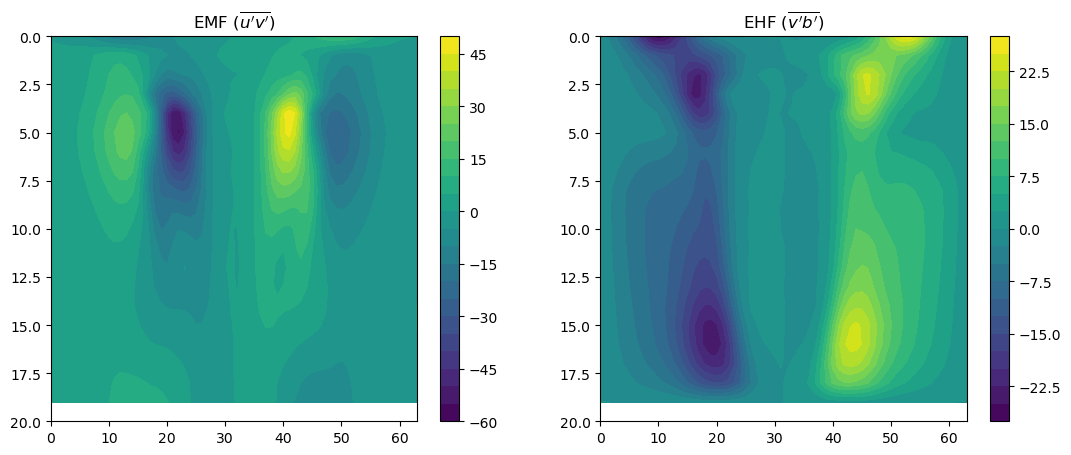

In [13]:
fig, (ax1,ax2) = plt.subplots(1,2, dpi=100, figsize=(13,5))
cs1 = ax1.contourf(emf_mean.mean(axis=(0,3)), levels=21)
plt.colorbar(cs1)
ax1.set_ylim([20,0])
ax1.set_title(r"EMF ($\overline{u'v'}$)")

cs2 = ax2.contourf(ehf_mean.mean(axis=(0,3)), levels=21)
plt.colorbar(cs2)
ax2.set_ylim([20,0])
ax2.set_title("EHF ($\overline{v'b'}$)")



## $\theta$ and $\partial \theta$

In [172]:
adiag = AtmosphericDiagnostics(u[2000:4000], v[2000:4000], t[2000:4000], p[2000:4000], z[2000:4000])
theta = adiag.cal_theta()  
dtheta, dtheta_zm = adiag.dtheta() 


Computing ∂θ/∂z ...


In [173]:
theta.shape

(2000, 20, 64, 128)

Text(0.5, 1.0, '$\\partial \\theta$')

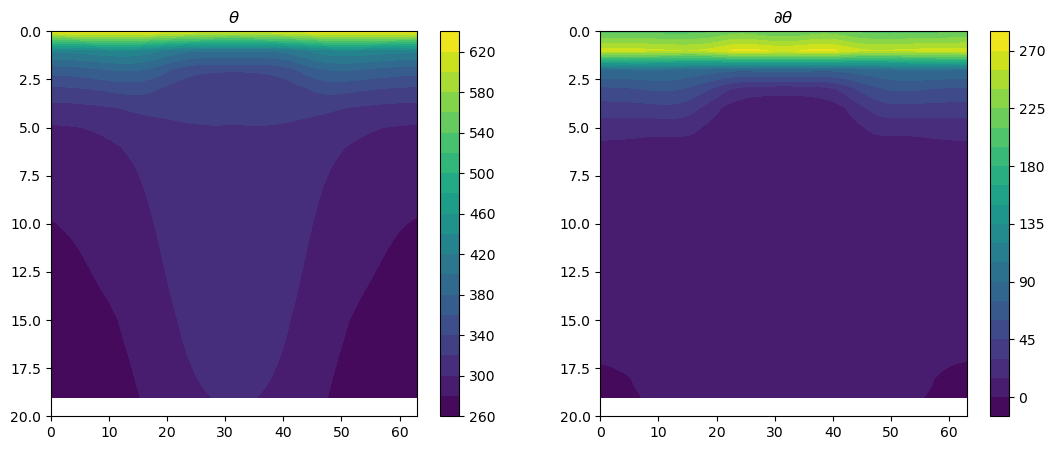

In [174]:
fig, (ax1,ax2) = plt.subplots(1,2, dpi=100, figsize=(13,5))
cs1 = ax1.contourf(theta.mean(axis=(0,3)), levels=21)
plt.colorbar(cs1)
ax1.set_ylim([20,0])
ax1.set_title(r"$\theta$")

cs2 = ax2.contourf(dtheta.mean(axis=(0,3)), levels=21)
plt.colorbar(cs2)
ax2.set_ylim([20,0])
ax2.set_title(r"$\partial \theta$")



In [29]:
# dx_along_axis
adiag = AtmosphericDiagnostics(u[2000:4000], v[2000:4000], t[2000:4000], p[2000:4000], z[2000:4000])
theta = adiag.cal_theta()  
print(theta.shape)
dtheta, dtheta_zm = adiag.dx_along_axis(theta, axis=1) 


(2000, 20, 64, 128)
Computing ∂(x)/∂(axis 1) ...


Text(0.5, 1.0, '$\\partial \\theta$')

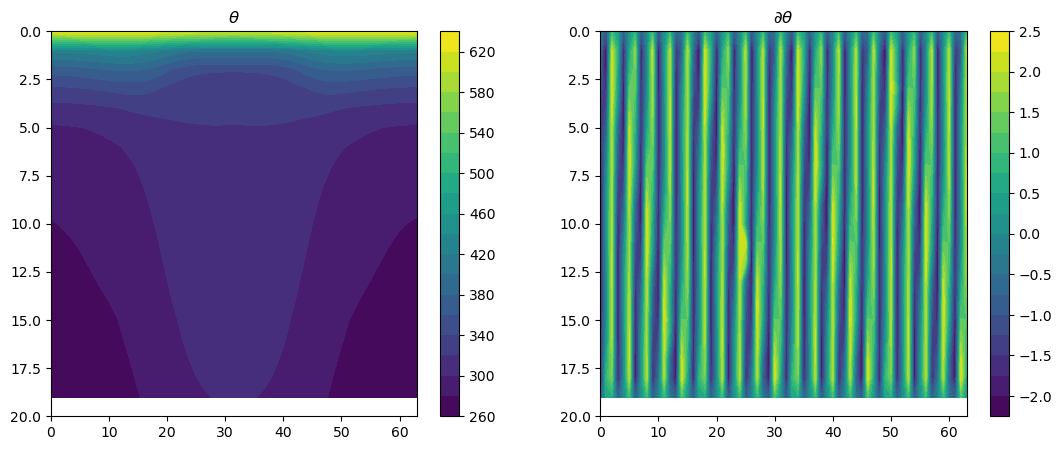

In [30]:
fig, (ax1,ax2) = plt.subplots(1,2, dpi=100, figsize=(13,5))
cs1 = ax1.contourf(theta.mean(axis=(0,3)), levels=21)
plt.colorbar(cs1)
ax1.set_ylim([20,0])
ax1.set_title(r"$\theta$")

cs2 = ax2.contourf(dtheta.mean(axis=(0,3)), levels=21)
plt.colorbar(cs2)
ax2.set_ylim([20,0])
ax2.set_title(r"$\partial \theta$")



In [25]:
adiag = AtmosphericDiagnostics(u[2000:4000], v[2000:4000], t[2000:4000], p[2000:4000], z[2000:4000])
dz, dz_zm = adiag.dx_along_axis(z[2000:4000], axis=1) 

Computing ∂(x)/∂(axis 1) ...


Text(0.5, 1.0, '$\\partial z$')

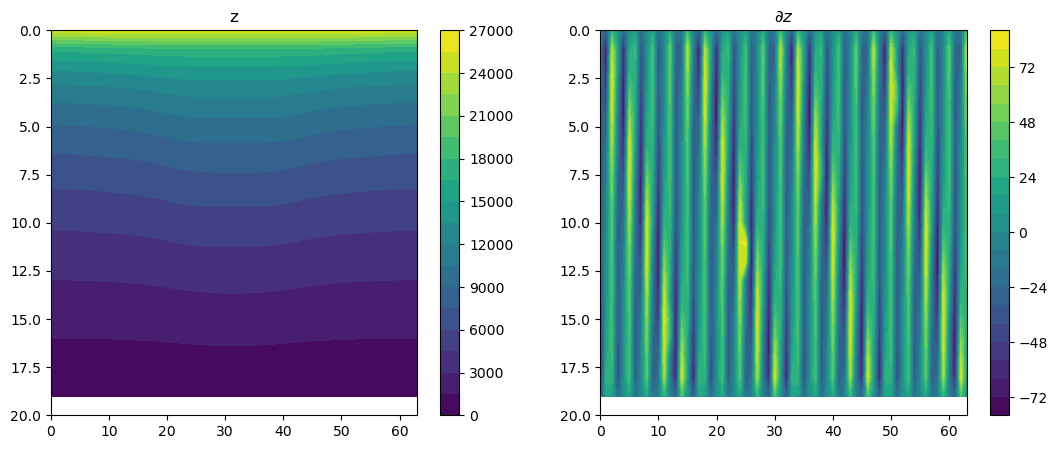

In [26]:
fig, (ax1,ax2) = plt.subplots(1,2, dpi=100, figsize=(13,5))
cs1 = ax1.contourf(z.mean(axis=(0,3)), levels=21)
plt.colorbar(cs1)
ax1.set_ylim([20,0])
ax1.set_title(r"z")

cs2 = ax2.contourf(dz.mean(axis=(0,3)), levels=21)
plt.colorbar(cs2)
ax2.set_ylim([20,0])
ax2.set_title(r"$\partial z$")



## Cal N2

In [84]:
start_idx = 2000
end_idx   = 4000
adiag = AtmosphericDiagnostics(u[start_idx:end_idx], v[start_idx:end_idx], t[start_idx:end_idx], p[start_idx:end_idx], z[start_idx:end_idx])
N2 = adiag.Cal_N_square()

[ 1844.2168  7376.867  12448.458  17485.873  22512.385  27533.992
 32552.914  37570.32   42586.7    47602.445  52617.613  57632.42
 62646.91   67661.28   72675.39   77689.53   82703.414  87717.27
 92730.89   97744.66  ]
[[[-5.02824461e-02 -5.03041238e-02 -5.03288471e-02 ... -5.10100481e-02
   -5.11001330e-02 -5.11529609e-02]
  [-2.45193297e-02 -2.45326493e-02 -2.45503611e-02 ... -2.49461526e-02
   -2.49912403e-02 -2.50124711e-02]
  [-8.80533993e-03 -8.82150806e-03 -8.84711159e-03 ... -9.09603946e-03
   -9.10124143e-03 -9.10127000e-03]
  ...
  [-5.31402302e-05 -5.77879019e-05 -6.67609644e-05 ... -6.26373184e-05
   -5.47464500e-05 -5.12516130e-05]
  [ 4.71300099e-05  3.84464663e-05  2.41204632e-05 ...  2.77576894e-05
    3.69420619e-05  3.92228234e-05]
  [ 1.74618771e-04  1.60601065e-04  1.38665435e-04 ...  1.41692936e-04
    1.53044162e-04  1.54109188e-04]]]


In [77]:
print(N2.min(), N2.max())

-0.054796669637423495 0.0001746187713322982


In [78]:
f0_array = adiag.f0()[np.newaxis, np.newaxis, :, np.newaxis]
ratio = f0_array / N2

print("N² min/max:", np.nanmin(N2), np.nanmax(N2))
print("f₀/N² min/max/mean:", np.nanmin(ratio), np.nanmax(ratio), np.nanmean(ratio))

ValueError: operands could not be broadcast together with shapes (1,1,64,1) (1,20,64) 

AxisError: axis 3 is out of bounds for array of dimension 3

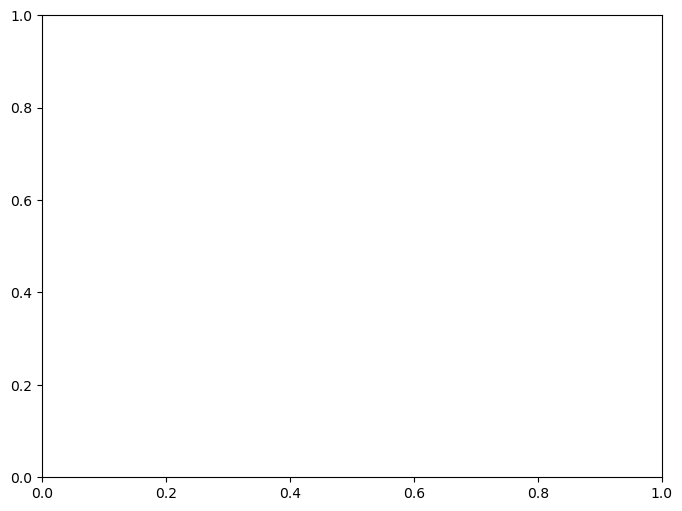

In [79]:
fig, ax = plt.subplots(dpi=100., figsize=(8,6))
plt.contourf(N2.mean(axis=(0,3)), levels=21)
plt.colorbar()
plt.ylim([20,0])
plt.title("$N^2$")

In [85]:
N2.shape

(1, 20, 64)

Text(0.5, 1.0, '$f0/N^2$')

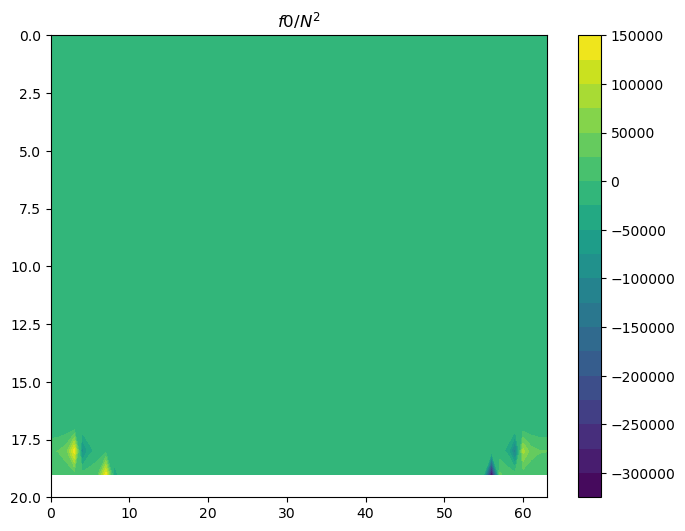

In [88]:
lat = adiag.lat
fig, ax = plt.subplots(dpi=100., figsize=(8,6))
plt.contourf(1/(N2).mean(axis=(0)) , levels=21)
plt.colorbar()
plt.ylim([20,0])
plt.title("$f0/N^2$")

## $\partial \theta \over \partial p$

In [1132]:
start_idx = 2000
end_idx   = 4000
adiag = AtmosphericDiagnostics(u[start_idx:end_idx], v[start_idx:end_idx], t[start_idx:end_idx], p[start_idx:end_idx], z[start_idx:end_idx])
dtheta_dp = adiag.dtheta_dp_columnwise()

Text(0.5, 1.0, '$\\frac{\\partial \\theta}{\\partial p}$')

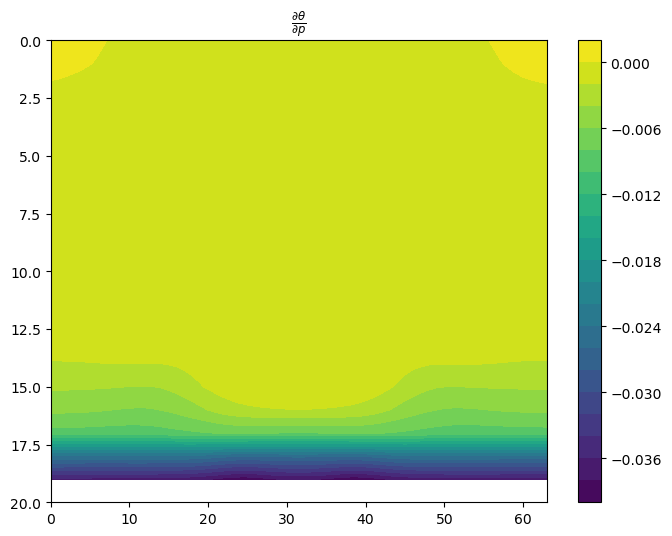

In [1149]:
fig, ax = plt.subplots(dpi=100., figsize=(8,6))
plt.contourf((dtheta_dp).mean(axis=(0,3)) , levels=21)
plt.colorbar()
plt.ylim([20,0])
plt.title(r"$\frac{\partial \theta}{\partial p}$")


# EP flux 

In [128]:
start_idx = 5000
end_idx   = 7000
adiag = AtmosphericDiagnostics(u[start_idx:end_idx], v[start_idx:end_idx], t[start_idx:end_idx], p[start_idx:end_idx], z[start_idx:end_idx])
Fj, Fk, EHF_dthdp = adiag.ep_flux()
        # print(ehf_zm.shape, N2.shape, F_j.shape)


EMF and EHF progress:
[########################################] | 100% Completed | 311.60 ms
[########################################] | 100% Completed | 310.48 ms
[ 1843.5975  7374.39   12444.266  17480.031  22504.852  27524.732
 32542.023  37557.727  42572.426  47586.414  52599.99   57613.12
 62626.06   67638.63   72651.12   77663.625  82675.73   87687.74
 92700.     97711.84  ]
[[[-5.01765702e-02 -5.02079506e-02 -5.02597516e-02 ... -5.03206494e-02
   -5.02634801e-02 -5.02238642e-02]
  [-2.44787199e-02 -2.45051171e-02 -2.45420117e-02 ... -2.45251545e-02
   -2.45117144e-02 -2.44988464e-02]
  [-8.83160891e-03 -8.85342981e-03 -8.88492474e-03 ... -8.88851877e-03
   -8.87888203e-03 -8.87169888e-03]
  ...
  [-4.92924909e-05 -5.35681240e-05 -6.32480073e-05 ... -7.87346236e-05
   -6.87400290e-05 -6.35949910e-05]
  [ 6.33325036e-05  5.74053125e-05  4.15295135e-05 ...  2.67992041e-05
    4.59142962e-05  5.66747536e-05]
  [ 2.06581211e-04  1.98461340e-04  1.74041577e-04 ...  1.61371127e-04
  

In [129]:
# with h5py.File(os.path.join(r"/data92/PeterChang/back_to_master1220/Moist_Dycore/", f"ep_flux.h5"), "w") as f:
#     f.create_dataset("Fj", data=Fj)
#     f.create_dataset("Fk", data=Fk)
    

In [130]:
EHF_dthdp.shape

(2000, 20, 64)

In [131]:
print(Fj.min(), Fj.max())
print(Fk.min(), Fk.max())



-212.38194 213.4283
-129.20220091098858 161.8294166437128


In [132]:
Fk.shape

(2000, 20, 64)

In [133]:
# Fj_mean = Fj.mean(axis=(0,3))
# Fk_mean = Fk.mean(axis=(0,3))
Fj_mean = Fj.mean(axis=(0))  # shape: (z, y)
Fk_mean = Fk.mean(axis=(0))  # shape: (z, y)
Fk_mean.shape

(20, 64)

In [134]:
print(Fj_mean.min(), Fj_mean.max())
print(Fk_mean.min(), Fk_mean.max())



-48.67431 55.625065
-36.1235598319555 34.817559607219124


In [135]:
# 

Text(0.5, 1.0, 'Fk')

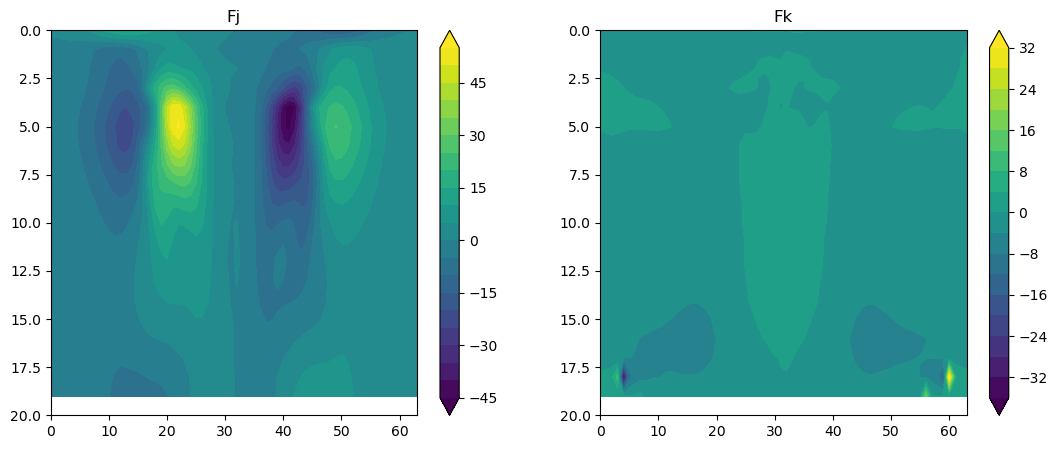

In [136]:
fig, (ax1,ax2) = plt.subplots(1,2, dpi=100, figsize=(13,5))
cs1 = ax1.contourf(Fj_mean, levels=21, extend="both")
plt.colorbar(cs1)
ax1.set_ylim([20,0])
ax1.set_title(r"Fj")

cs2 = ax2.contourf(Fk_mean, levels=21, extend="both")
plt.colorbar(cs2)
ax2.set_ylim([20,0])
ax2.set_title(r"Fk")



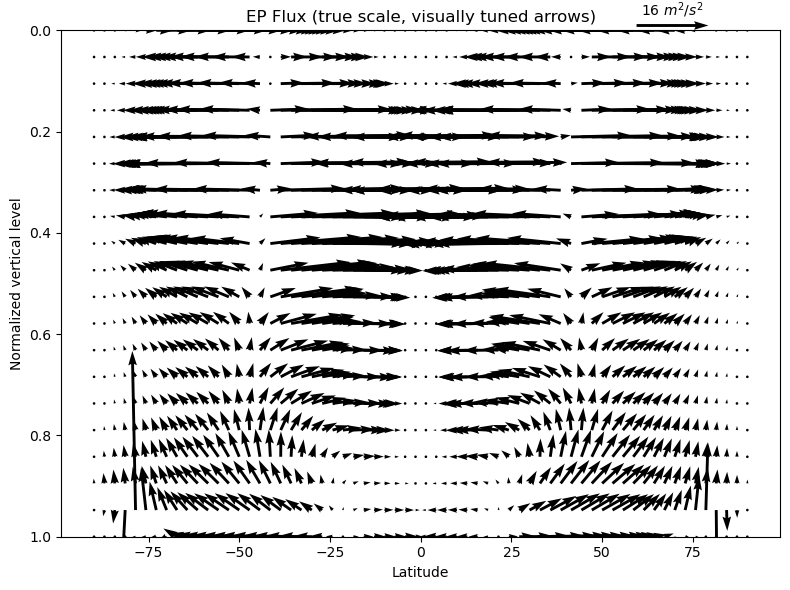

In [137]:
# 1. 根據 EP flux 的 magnitude 決定箭頭代表的單位
magnitude = np.sqrt(Fj_mean**2 + Fk_mean**2)
ref_arrow_size = np.nanpercentile(magnitude, 90)  # 第90百分位箭頭作為參考箭頭

# 2. quiver scale 控制「箭頭畫多長」
quiver_scale = 10 * ref_arrow_size  # 調這個會改箭頭長度（越大箭越短）

# 3. Plot
y = np.linspace(-90,90,64)
z_nor = np.linspace(0,1,20)
yy, zz = np.meshgrid(y, z_nor)

fig, ax = plt.subplots(1, figsize=(8, 6), dpi=100)
wind_plt = ax.quiver(
    yy[::, ::], zz[::, ::],
    Fj_mean[::, ::], -Fk_mean[::, ::],
    color="black", width=4e-3, scale=quiver_scale
)

# 4. Quiver key，只是圖例，不改數值
ax.quiverkey(
    wind_plt, X=0.85, Y=1.01,
    U=ref_arrow_size,
    label=f"{ref_arrow_size:.0f} $m^2/s^2$",
    labelpos='N', labelsep=0.05, color='black'
)

ax.set_ylim([1, 0])
ax.set_xlabel("Latitude")
ax.set_ylabel("Normalized vertical level")
plt.title("EP Flux (true scale, visually tuned arrows)")
plt.tight_layout()
plt.show()


In [1189]:
# # Read test
# with h5py.File(os.path.join(r"/data92/PeterChang/back_to_master1220/Moist_Dycore/", f"ep_flux.h5"), "r") as f:
#     Fj_test = f["Fj"][:]
#     Fk_test = f["Fk"][:]
    
    

In [1190]:
Fj.shape

(2000, 20, 64)